In [ ]:
# @title
%%html
<div style="color:#219ebc; font-family:Helvetica, Arial, sans-serif; font-size:35px; font-weight:700; text-align:center;">
  Cellular Metabolism
</div>
<div style="color:#219ebc; font-family:Helvetica, Arial, sans-serif; font-size:35px; font-style:italic; text-align:center; margin-top:6px;">
  Identifying an unknown metabolic inhibitor
</div>

# Overall objectives of the biochemistry lab practical


In this practical, you will combine results from **three complementary assays** to build a “response fingerprint” that helps you ***identify an unknown metabolic inhibitor/mitochondrial modulator***. Each assay reports on a different aspect of cell physiology (*inflammation-related signaling output*, *cell membrane integrity/viability*, and *mitochondrial function*) so that, together, they provide a much stronger basis for identifying the compound than any single assay alone. By the end, and with the help of this Jupyter/Python data analysis notebook, you will summarize your results in a **compound × assay response matrix** and use it to argue which unknown compound best matches your observed pattern.

---

**Assay 1: JC-1 assay (mitochondrial membrane potential, ΔΨm):**  
The dye *JC-1* accumulates in mitochondria in a membrane potential–dependent manner. Healthy, polarized mitochondria show more ***red*** fluorescence (JC-1 aggregates), while depolarized mitochondria show more ***green*** fluorescence (JC-1 monomers). The key readout is the ***red/green fluorescence ratio***, which reflects changes in *mitochondrial membrane potential (ΔΨm)*. This assay is especially informative for compounds that directly perturb the electron transport chain, ATP synthase, or proton gradient.

**Assay 2: LDH assay (cytotoxicity / membrane damage):**  
*Lactate dehydrogenase (LDH)* is a stable enzyme found inside cells. When the plasma membrane is damaged, LDH leaks into the medium. By measuring LDH activity in the *culture medium* (released LDH) and comparing it with LDH in the *cell lysate* (intracellular/total LDH), you can estimate ***cell damage or cytotoxicity*** (often expressed as % LDH released). This helps you distinguish “reduced function” from “cells are simply dying.”

**Assay 3: Griess assay (nitrite/NO₂⁻ production):**  
In BV2 microglia, inflammatory stimulation leads to nitric oxide (NO) production, which is converted into *nitrite (NO₂⁻)* in the medium. The *Griess reaction* converts nitrite into a colored product that can be measured by absorbance. This assay therefore reports the ***inflammatory output*** of cells and how it changes when metabolism is perturbed by the unknown compound.


> **Note:** For simplicity and didatic reasons, in this Jupyter notebook, we change the order in which the assays are presented compared to the practical's manual. The order in which the assays were perform does not matter here, as they are independent from on another. However, for the data analysis part, it's important to ***run all cells*** in order.


## Candidate compounds and their primary targets

| Compound | Main enzyme/complex/process targeted |
|---|---|
| 2-Deoxyglucose (2DG) | **Hexokinase** (glycolysis entry step) |
| Iodoacetate (IA) | **GAPDH** (glyceraldehyde-3-phosphate dehydrogenase; glycolysis) |
| CP-316819 | **Glycogen phosphorylase** (glycogen breakdown) |
| Fluoroacetate (FA) | **Aconitase** (TCA cycle; via fluorocitrate) |
| 3-Nitropropionic acid (3NPA) | **Succinate dehydrogenase** (Complex II; TCA/ETC link) |
| FCCP | **Oxidative phosphorylation uncoupler** (collapses proton gradient) |
| Oligomycin (OM) | **ATP synthase** (Complex V) |
| Rotenone | **Complex I** (NADH dehydrogenase) |

<br>

---

## Setup: install packages

If you are running in **Google Colab**, run the cell below once.  
If everything already imports fine, you can skip it.


In [ ]:
# Colab setup (safe to re-run)
%pip -q install openpyxl scipy seaborn

print("✅ Dependencies installed.")


✅ Dependencies installed.


It might be necessary to mount your Google Drive and connect it to Colab.

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive/')

## Setup: imports and small helper functions

This cell loads the libraries we need:

- **pandas / numpy** for data handling
- **matplotlib / seaborn** for plotting
- **scipy.stats** for basic statistics

It also defines a consistent color scheme and a small helper for ordering groups in plots.

In [ ]:
# =========================
# Imports
# =========================

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from scipy import stats
from IPython.display import display  # for nice tables in notebooks

# Silence noisy warnings that distract students
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# Helper utilities (used throughout the notebook)
# -------------------------
def ok(message: str) -> None:
    """Print a checkmark so teachers know the cell ran successfully."""
    print(f"✅ {message}")

def assert_dataframe(df: pd.DataFrame, *, name: str, required_cols=None, min_rows: int = 1) -> None:
    """Small sanity checks to make cells safer."""
    assert isinstance(df, pd.DataFrame), f"{name} is not a pandas DataFrame (got {type(df)})."
    assert df.shape[0] >= min_rows, f"{name} has {df.shape[0]} rows, expected ≥ {min_rows}."
    if required_cols is not None:
        required_cols = set(required_cols)
        missing = required_cols.difference(df.columns)
        assert not missing, f"{name} is missing required columns: {sorted(missing)}"

def assert_nonempty_list(x, *, name: str) -> None:
    assert isinstance(x, (list, tuple)), f"{name} should be a list/tuple."
    assert len(x) > 0, f"{name} is empty."


# -------------------------
# Plot settings (you can change these)
# -------------------------


# If you want slightly larger default figures in the notebook:
plt.rcParams["figure.figsize"] = (10, 6)

# Seaborn settings
sns.set_context("talk")
sns.set_palette("Set2")

CBAR_LABEL = "Absorbance (OD490)"

# Consistent colors across plots
COLOR_PALETTE = sns.color_palette("Set2", n_colors=7)
COLOR_MAP = {
    "Negative Control": COLOR_PALETTE[0],
    "Positive Control": COLOR_PALETTE[1],
    "Unknown A": COLOR_PALETTE[2],
    "Unknown B": COLOR_PALETTE[3],
    "Unknown C": COLOR_PALETTE[4],
    "Unknown D": COLOR_PALETTE[5],
    "DMSO Control": COLOR_PALETTE[6],
}

# Default order for plots (controls first, then unknowns)
PLOT_ORDER_DEFAULT = [
    "Negative Control",
    "Positive Control",
    "Unknown A",
    "Unknown B",
    "Unknown C",
    "Unknown D",
]

# For cleaning up "Positive P" / "Negative N" labels into consistent control names
CONTROL_RENAME = {
    "Negative N": "Negative Control",
    "Negative": "Negative Control",
    "Positive P": "Positive Control",
    "Positive": "Positive Control",
}

ok("Imports + helper functions loaded.")


✅ Imports + helper functions loaded.


## A little about 'assert'

In [ ]:
# =========================
# Step 0: Learning about 'assert'
# =========================

# 🌟 'assert' statements allow you to say what you expect from your code
# we can use it to catch errors early and throw an error
# I use them to check mistakes I anticipate we might make but there are so
# many other possible mistakes, so don't rely on 'assert' alone!

# CAKE = None

# assert CAKE is not None, "CAKE should not be None here ❌"

# print("✅ Assert statement worked! But still no cake...")

# Assay 1: The JC‑1 assay (mitochondrial membrane potential, ΔΨm)


**JC‑1** is a cationic dye that accumulates in mitochondria in a **ΔΨm‑dependent** manner:

1. In **healthy / polarized** mitochondria (high ΔΨm), JC‑1 forms **J‑aggregates** that fluoresce **red**.
2. In **depolarized** mitochondria (low ΔΨm), JC‑1 remains as **monomers** that fluoresce **green**.
3. The key readout is therefore the **Red/Green ratio** (often aggregate/monomer signal), which serves as a *relative* indicator of ΔΨm.

**How to interpret the ratio**
- **Higher Red/Green** → more polarized mitochondria (higher ΔΨm), generally consistent with intact mitochondrial function.
- **Lower Red/Green** → mitochondrial depolarization (lower ΔΨm), which can indicate mitochondrial dysfunction or early cell stress (interpret alongside LDH to separate dysfunction from outright cytotoxicity).

**Important practical notes**
- JC‑1 is **light sensitive**: minimize light exposure and keep timing consistent across the plate.
- Reader settings must match the protocol (typical channels: **green ~530 nm**, **red ~590 nm**; exact wavelengths depend on your instrument).
- Include appropriate controls when available (e.g., a depolarizing control such as **CCCP/FCCP**) to validate that the assay is responding as expected.
- Ratio metrics reduce some well-to-well variation, but you should still handle **background/blank correction** and **replicate structure** carefully.

---
**How to actually do this?**

In order to see the effect of our compounds on cells' mitonchondrial activity, we need to:
1) Substract the blank state of a well from its color
2) For each well, calculate the Red/Green flurescence ratio
3) Average the ratios over all measerements for each compound (the 12 measurement rows)
4) Visualise the R/G ratio of each unknown compound with the 3 controls using a plot


## Step 1.1 - Load and inspect the plate export

We load the exported Excel sheet into a **pandas DataFrame**.  
A DataFrame is like a spreadsheet with extra superpowers (filtering, reshaping, grouping, etc.).

**Expected file location:** `/content/Assay_1_MMC_JC1_sample_data.xlsx`  
If your file is elsewhere, update the path below.

**What this code cell does (Step 1.1 — Load and inspect the plate export, part 1/5)**

- Loads the JC‑1 plate reader export from Excel into a pandas DataFrame (`mmc`).
- Runs basic sanity checks to ensure the file has the expected structure (required columns, at least one row).
- Detects the 12 measurement columns (1–12) that correspond to plate columns.

In [ ]:
# ==================================================
# Step 1.1: Loading and Checking the file's integrity
# ==================================================

# We'll be using a python package called pandas to deal with our data
# It turns our excel file into a "dataframe" and gives us some ready-made functions to deal with it
# We'll do some basic things now to get a grasp, some more advanced ones later
# You can always check the documentation here: https://pandas.pydata.org/docs/user_guide/index.html
# Or have a cheat sheet open at all time: https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf
# It may be hard to understand right now, but eventually you'll start remembering the vocabulary
# Once you get used to the lingo, you can more easily ask your favourite llm for quick advice


# Let's start by loading the data file
mmc = pd.read_excel("/content/Assay_1_MMC_JC1_sample_data.xlsx")


# --- Sanity checks (shared with the LDH notebook) ---
assert_dataframe(mmc, name="mmc", required_cols={"Well", "Labels", "Color"}, min_rows=1)

mmc_plate_columns = [c for c in mmc.columns if str(c).strip().isdigit()]
mmc_plate_columns = sorted(mmc_plate_columns, key=lambda x: int(str(x)))
assert_nonempty_list(mmc_plate_columns, name="mmc_plate_columns")
assert [int(str(c)) for c in mmc_plate_columns] == list(range(1, 13)), (
    f"Expected numeric columns 1..12. Found: {[str(c) for c in mmc_plate_columns]}"
)

ok("Assay 1 data loaded.")

# what's its shape?
mmc.shape # 16 rows, 15 columns

✅ Assay 1 data loaded.


(17, 15)

In [ ]:
# What variables (columns) do we have available?
mmc.columns

# We can see the 1st excel row was automatically turned into our column header/variable names, neat!

Index(['Color', 'Well', 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 'Labels'], dtype='object')

In [ ]:
# What does the dataset look like?
mmc

,Color,Well,1,2,3,4,5,6,7,8,9,10,11,12,Labels
0,Green,A,66,77,68,70,70,75,73,77,76,66,69,68,Blank
1,Green,B,173,162,158,163,166,175,182,177,184,176,170,158,Negative Control
2,Green,C,223,239,246,227,216,207,229,251,214,232,213,214,Unknown A
3,Green,D,440,432,401,435,444,425,422,396,443,439,417,400,Unknown B
4,Green,E,365,397,359,378,385,393,338,373,362,343,339,364,Unknown C
5,Green,F,148,143,137,154,147,136,135,149,142,135,135,143,Unknown D
6,Green,G,180,172,181,177,181,173,163,172,159,157,183,166,DMSO Control
7,Green,H,472,528,575,501,561,518,558,547,534,485,494,524,Positive Control
8,Color,Well,1,2,3,4,5,6,7,8,9,10,11,12,Labels
9,Red,A,78,84,80,83,74,73,86,75,73,78,73,79,Blank


In [ ]:
# The dataset is relatively small here, but we will eventually deal with much larger datasets
# To get a quick overview of a dataset, we can easily subset some rows
## let's say we want to only look at the top 4 rows:
#mmc.head(4)
## or 5 bottom rows:
#mmc.tail(5)
## or a random sample of 6 rows:
mmc.sample(5)

# Let's take a look at the whole thing again and try to understand it
mmc

,Color,Well,1,2,3,4,5,6,7,8,9,10,11,12,Labels
0,Green,A,66,77,68,70,70,75,73,77,76,66,69,68,Blank
1,Green,B,173,162,158,163,166,175,182,177,184,176,170,158,Negative Control
2,Green,C,223,239,246,227,216,207,229,251,214,232,213,214,Unknown A
3,Green,D,440,432,401,435,444,425,422,396,443,439,417,400,Unknown B
4,Green,E,365,397,359,378,385,393,338,373,362,343,339,364,Unknown C
5,Green,F,148,143,137,154,147,136,135,149,142,135,135,143,Unknown D
6,Green,G,180,172,181,177,181,173,163,172,159,157,183,166,DMSO Control
7,Green,H,472,528,575,501,561,518,558,547,534,485,494,524,Positive Control
8,Color,Well,1,2,3,4,5,6,7,8,9,10,11,12,Labels
9,Red,A,78,84,80,83,74,73,86,75,73,78,73,79,Blank


You should see two blocks of measurements:

- 8 wells (A–H) for each **Color** channel (Green and Red)
- 12 measurement columns (1–12)
- A **Labels** column mapping each well to a compound/control
- Sometimes plate reader exports include an extra row that repeats headers — we’ll remove it next.

In [ ]:
# Alright, we can start getting a sense of the data and its structure
## It contains 2 matrices corresponding to:
## 12 measurements (recorded in columns 1 to 12) in 8 wells (A-H, indicated by the value in column "Well").
## Each well contains a different compound (indicated by the value in the "Labels" column)
## Each matrix is a different colour chanel (Green or Red, indicated in the perfectly named column: "Color")
## We do have an extra row (row number 8) that just repeats the column names

# we can select a specific row using the iloc method and the row index we want to examine
mmc.iloc[5] # this returns the Green chanel measurements for Well F, which contains compound D

# We can also select a range of rows, for example, all Green chanel measurements are between index 0 and 8:
mmc.iloc[0:8] # /!\ PYTHON INDEXES AT 0, the 1st row is always 0, the 2nd is 1, ect

# Note that we can also filter our dataset using the variable names
## For that, we'll use the .loc method
mmc.loc[mmc["Color"] == "Green"]
# Why is that better?

,Color,Well,1,2,3,4,5,6,7,8,9,10,11,12,Labels
0,Green,A,66,77,68,70,70,75,73,77,76,66,69,68,Blank
1,Green,B,173,162,158,163,166,175,182,177,184,176,170,158,Negative Control
2,Green,C,223,239,246,227,216,207,229,251,214,232,213,214,Unknown A
3,Green,D,440,432,401,435,444,425,422,396,443,439,417,400,Unknown B
4,Green,E,365,397,359,378,385,393,338,373,362,343,339,364,Unknown C
5,Green,F,148,143,137,154,147,136,135,149,142,135,135,143,Unknown D
6,Green,G,180,172,181,177,181,173,163,172,159,157,183,166,DMSO Control
7,Green,H,472,528,575,501,561,518,558,547,534,485,494,524,Positive Control


## Step 1.2 - Clean the dataset (Data Wrangling)

Idea: Remove any non-data rows and drop redundant columns.

**What this code cell does (Step 1.2 — Clean the dataset (Data Wrangling))**

- Demonstrates two common ways to subset a DataFrame:
  - `iloc[...]` for selecting rows by position (row number).
  - `loc[...]` for filtering rows by a condition (e.g., only the Green channel).


In [ ]:
# =========================
#  Step 1.2 Data Wrangling
# =========================

# Where we start changing things around

# There is an odd row in the middle of our dataset:
mmc.iloc[8] # What does this return?

# Let's remove it, as it could mess up our analyses
mmc = mmc.drop(8) # since we know the index, we could simply use the .drop method, but what if the index was different?
# It is always more robust to do data operations using a "conditional statement"

## In our case, we know that if the value in the Color column is not Green or Red, the row should be discarded
## Let's filter based on that condition, then our script is more robust!
## we can use the .isin method to text if aa value is in a list
mmc = mmc.loc[mmc["Color"].isin(["Green", "Red"])]

# Also, the "Well" column is redundant. Since we only have one Well per Compound, the Label variable is enough
## We can seafely remove it and continue our analysis
mmc_wide = mmc.drop(["Well"], axis=1)


# Let's print the data again
mmc_wide
# Note that I called my dataset mmc_wide
# Wide is what we call a dataset where each row represents a subject (here, a compound)
# and each column a variable describing that subject

,Color,1,2,3,4,5,6,7,8,9,10,11,12,Labels
0,Green,66,77,68,70,70,75,73,77,76,66,69,68,Blank
1,Green,173,162,158,163,166,175,182,177,184,176,170,158,Negative Control
2,Green,223,239,246,227,216,207,229,251,214,232,213,214,Unknown A
3,Green,440,432,401,435,444,425,422,396,443,439,417,400,Unknown B
4,Green,365,397,359,378,385,393,338,373,362,343,339,364,Unknown C
5,Green,148,143,137,154,147,136,135,149,142,135,135,143,Unknown D
6,Green,180,172,181,177,181,173,163,172,159,157,183,166,DMSO Control
7,Green,472,528,575,501,561,518,558,547,534,485,494,524,Positive Control
9,Red,78,84,80,83,74,73,86,75,73,78,73,79,Blank
10,Red,673,599,562,651,570,624,582,640,571,671,601,614,Negative Control


## Step 1.3 - Background (blank) subtraction

Why subtract a blank?
- Plate reader data often contains **background fluorescence** (media, plastic, reagent autofluorescence).
- Subtracting the **blank well** helps isolate the signal that comes from the biological sample.

We will:
1. Extract the blank values for Green and Red
2. Remove blank rows from the dataset
3. Subtract the appropriate blank from each row (Green-from-Green, Red-from-Red)

**What this code cell does (Step 1.3 — Background (blank) subtraction)**

- Extracts the blank (background) fluorescence values separately for the Green and Red channels.
- Removes the blank rows from the main dataset and subtracts the background from every measurement column (1–12).
- Creates a corrected dataset (`mmc_wide_corrected`) that is ready for ratio calculation.


In [ ]:
# ==================================
# Step 1.3:  Substracting the blank
# ==================================

# Remind me, why are we substracting a blank state here?


# Let's start by saving the values of our blank states in different variables
## For that, we use conditional statements
## Note that we subset the column 1 to 12 (1:12)
blank_green = mmc_wide.loc[(mmc_wide["Labels"] == "Blank") & (mmc_wide["Color"] == "Green"), 1:12]
blank_red = mmc_wide.loc[(mmc_wide["Labels"] == "Blank") & (mmc_wide["Color"] == "Red"), 1:12]
# We can then remove the blank states from the dataset
mmc_wide_no_blank = mmc_wide.loc[(mmc_wide["Labels"] != "Blank")]

# Let's check
blank_green
blank_red
mmc_wide_no_blank

# we can now use the .sub method to subtract the blank values to each row simultaneously
## We first copy the data, this ensures that even if we repeat the operation, we get reliable output
mmc_wide_corrected = mmc_wide_no_blank.copy() # what happens if you don't use the .copy method?
## We substract the background value for green from the green chanels
mmc_wide_corrected.loc[mmc_wide_no_blank["Color"] == "Green",1:12] = mmc_wide_no_blank.loc[mmc_wide_no_blank["Color"] == "Green",1:12].sub(blank_green.iloc[0], axis='columns')
## We substract the background value for red from the red chanels
mmc_wide_corrected.loc[mmc_wide_no_blank["Color"] == "Red",1:12] = mmc_wide_no_blank.loc[mmc_wide_no_blank["Color"] == "Red",1:12].sub(blank_red.iloc[0], axis='columns')

# We can compare the values between our 2 dataframes to make sure we did it correctly
mmc_wide_no_blank
mmc_wide_corrected
# Perfect 👍


,Color,1,2,3,4,5,6,7,8,9,10,11,12,Labels
1,Green,107,85,90,93,96,100,109,100,108,110,101,90,Negative Control
2,Green,157,162,178,157,146,132,156,174,138,166,144,146,Unknown A
3,Green,374,355,333,365,374,350,349,319,367,373,348,332,Unknown B
4,Green,299,320,291,308,315,318,265,296,286,277,270,296,Unknown C
5,Green,82,66,69,84,77,61,62,72,66,69,66,75,Unknown D
6,Green,114,95,113,107,111,98,90,95,83,91,114,98,DMSO Control
7,Green,406,451,507,431,491,443,485,470,458,419,425,456,Positive Control
10,Red,595,515,482,568,496,551,496,565,498,593,528,535,Negative Control
11,Red,360,363,304,346,369,378,361,383,375,346,377,319,Unknown A
12,Red,143,129,116,129,137,150,137,157,142,147,162,137,Unknown B


## Step 1.4 - Compute Red/Green ratios (reshaping wide → long → wide)

For ratio calculation, it’s convenient to:
1. Convert the 12 measurement columns into a **long format** (one row per measurement)
2. Pivot so Green and Red become **separate columns**
3. Compute **Ratio = Red / Green** for each compound and measurement

**What this code cell does (Step 1.4 — Compute Red/Green ratios (reshaping wide → long → wide), part 1/2)**

- Reshapes the corrected data from wide → long format so each measurement becomes a row (tidy data).
- Pivots the long table so Red and Green values end up as separate columns for each compound × measurement.
- Produces `mmc_long`, which makes calculating Red/Green ratios straightforward.

Later:
- Computes the Red/Green fluorescence ratio for each compound and measurement (`Ratio = Red / Green`).
- Creates a ratios-only table (`mmc_long_ratios`) for downstream summaries and plots.


In [ ]:
# =========================================================
# STEP 1.4: Convert to long format and calculate R/G ration
# =========================================================

# First, it'd be a lot easier to work with a long format data here
## This means that we will aggregate all the 12 measurement rows into 2 column:
##  1 for the measurement number, 1 for its fluorescence value
## For that, we'll melt the dataset using the .melt method
## This function turns a dataset from wide to long format
## It takes 3 arguments:
##  - id_vars: the variables that will be used to identify each row
##  - value_vars: the variables that will be used to create the new value column
##  - var_name: the name of the new variable that will be used to identify the value_vars
mmc_long = mmc_wide_corrected.melt(id_vars=["Labels", "Color"], value_vars=[1,2,3,4,5,6,7,8,9,10,11,12], var_name="Measurement")
mmc_long

# Second, now we want the Red and Green values to stand side by side in their own column
## For that, we do the reverse operation: .pivot
## This function turns a dataset from long to wide format:
## It takes 3 arguments:
##  - index: the variable that will be used to create the new index
##  - columns: the variable that will be used to create the new columns
##  - values: the variable that will be used to populate the new dataframe
mmc_long = mmc_long.pivot(index=["Labels", "Measurement"], columns="Color", values="value")
mmc_long # perfect👍

Color                     Green  Red
Labels       Measurement            
DMSO Control 1              114  559
             2               95  499
             3              113  496
             4              107  599
             5              111  533
...                         ...  ...
Unknown D    8               72  634
             9               66  544
             10              69  646
             11              66  562
             12              75  653

[84 rows x 2 columns]

In [ ]:
################## Calculate the R/G ratios ##################

# Now calculating the R/G ratios is as easy as this:
mmc_long["Ratio"] = mmc_long["Red"] / mmc_long["Green"]
# Then let's create a dataframe with the ratios only to avoid confusion
## we do that by dropping the Green and Red columns
mmc_long_ratios = mmc_long.drop(["Green", "Red"], axis=1)

mmc_long_ratios

Color                        Ratio
Labels       Measurement          
DMSO Control 1            4.903509
             2            5.252632
             3            4.389381
             4            5.598131
             5            4.801802
...                            ...
Unknown D    8            8.805556
             9            8.242424
             10           9.362319
             11           8.515152
             12           8.706667

[84 rows x 1 columns]

## Step 1.5 - Summarise ratios per compound

We typically summarise by **mean** and **standard deviation (SD)** across the 12 measurements.

**What this code cell does (Step 1.5 — Summarise ratios per compound)**

- Groups the ratio data by compound label and calculates the mean ratio across measurements.
- Adds a standard deviation (SD) to quantify how variable the 12 measurements are for each compound.
- Outputs a compact summary table (`mmc_summary_ratios`) used for interpretation and annotation.

In [ ]:
# ==============================================
# STEP 1.5: Averaging and summarizing the ratios
# ==============================================

# Now we can average the ratios over all measurements for each compound
## For that, we'll use the .groupby method
## This function groups the dataframe by the values of the specified column(s)
## and applies the specified function to each group seperately
## In our case, we group by Labels and apply the mean() function
mmc_summary_ratios = mmc_long_ratios.groupby("Labels").mean()
# Let's rename the variable for clarity
mmc_summary_ratios = mmc_summary_ratios.rename(columns= {'Ratio':'Mean'})
# To get an idea of the variation between measurements
# Let's add a column with the standard deviation of the ratios for each compound
mmc_summary_ratios["SD"] = mmc_long.groupby("Labels").std()["Ratio"]

# Let's see the results
mmc_summary_ratios
# So, what do we see?

########################### STEP 4.3 ###########################
############## export the summary to CSV and Excel #############
# Export to Excel
mmc_summary_ratios.to_excel("Assay1_mmc_jc1_results.xlsx")

## Step 1.6 - Visualise the results

### Boxplot
A boxplot is useful for comparing the distribution of ratio values between compounds/controls.

### Bar plot (optional)
A bar plot shows mean ratios. It’s simpler, but it hides the distribution unless you add error bars or overlay points.

**What this code cell does (Step 1.6 — Visualise the results, part 1/2)**

- Plots a boxplot of the Red/Green ratios for each compound to compare distributions (not just means).
- Formats the axes/labels and removes the redundant legend (color matches the x‑axis labels).
- Saves the figure as a PNG and displays it in the notebook.


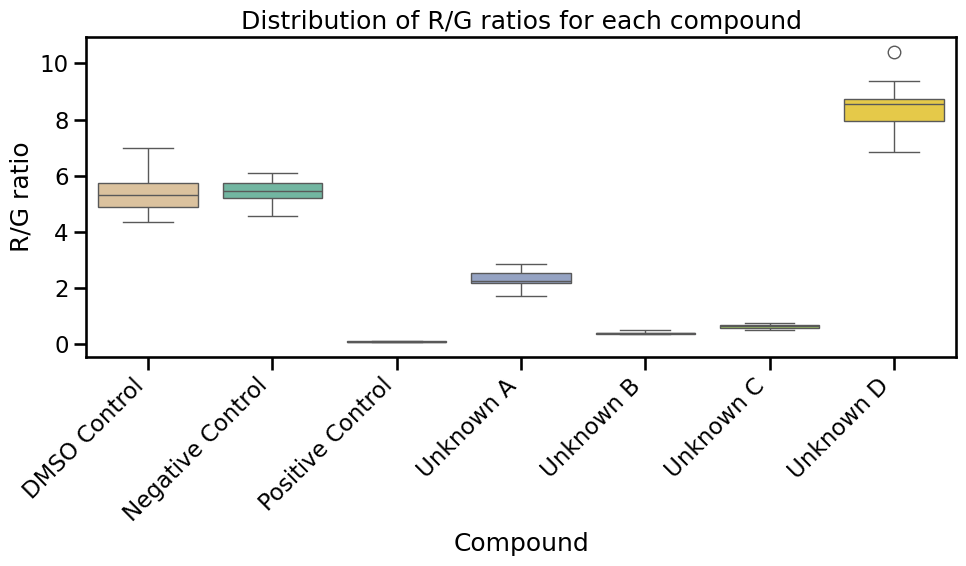

In [ ]:
# =================================
# STEP 1.6: Visualising the results
# =================================

# Now we'll make a boxplot
## It is useful to compare the distribution of a variable between groups
## It's a bit more complex to make than a simple barplot, but it's worth it
## Refer to the boxplot video from the Kvalitetsvurdering course on Absalon
## We'll use it to visualise the range of ratio values for each compound
## Then we can easily compare with the controls and infer what the compound did to the cells

# To plot, we're using a python package called seaborn
## It has lots of pre-made functions so we don't have to draw each line with mathematical functions
## As usual, you can check the documentation: https://seaborn.pydata.org/index.html
## You can always steal the code for some specific plot types from the gallery: https://seaborn.pydata.org/examples/index.html
## Once you get a better feel for it, check the tutorials: https://seaborn.pydata.org/tutorial.html

# Plotting usually follows some clear steps:
# 1. define the canvas
plt.figure(figsize=(10, 6))
## 2. define the layout and the data being plotted
sns.boxplot(x="Labels", y="Ratio", hue="Labels", data=mmc_long_ratios, palette=COLOR_MAP)
## 3. define the text
plt.title("Distribution of R/G ratios for each compound")
plt.xlabel("Compound")
plt.xticks(rotation=45,horizontalalignment='right')
plt.ylabel("R/G ratio")
## Since color is directly related to value on the x axis, we can remove the legend
plt.legend([],[], frameon=False)
# 4. save the plot (/!\ requires the plots folder to exist!)
plt.tight_layout()
plt.savefig("Assay1_mmc_jc1_ratios_boxplot.png")#
# 5. show the plot
plt.show()


**What this code cell does (Step 1.6 — Visualise the results, part 2/2)**

- Creates an alternative bar plot view of the ratios by compound (often easier to read than a boxplot).
- Adds text labels with the mean ratio values to support quick comparison between conditions.

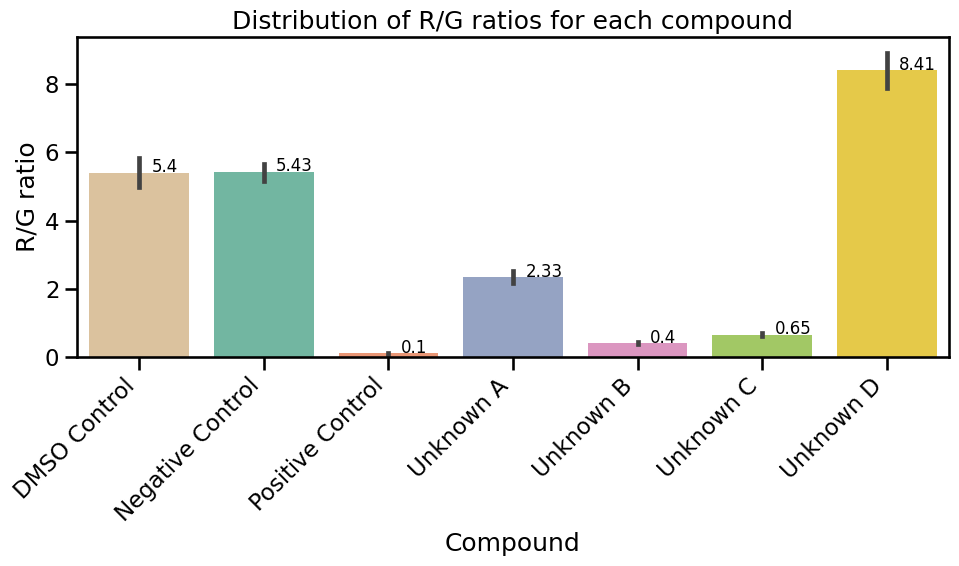

In [ ]:
# If you're not convinced by the boxplot, below is the code for the barplot
## Can you see the difference between the 2?

# 1. define the canvas
plt.figure(figsize=(10, 6))
## 2. define the layout
sns.barplot(x="Labels", y="Ratio", hue="Labels", data=mmc_long, palette=COLOR_MAP)

## Text in plot
plt.title("Distribution of R/G ratios for each compound")
plt.xlabel("Compound")
plt.xticks(rotation=45,horizontalalignment='right')
plt.ylabel("R/G ratio")
## Since color is directly related to value on the x axis, we can remove the legend
plt.legend([],[], frameon=False)
# We can even add the mean values directly on the plot
## For that, we loop through our summary dataframe
for i in range(len(mmc_summary_ratios)):
    plt.text(x = i+0.1 , y = mmc_summary_ratios.iloc[i,0]+0.02, s = round(mmc_summary_ratios.iloc[i,0],2), size = 12)

# save the plot (/!\ requires the plots folder to exist!)
plt.tight_layout()
plt.savefig("Assay1_mmc_jc1_ratio_barplot.png")

# show the plot
plt.show()

## Assay 1 - Interpretation

- Compare each unknown compound to your **controls** (e.g., untreated, positive control, etc.).
- A shift in the Red/Green ratio can indicate changes in **mitochondrial membrane potential**.
- Which compounds affect the mitocontrial potential the most, compared to the controls? Which ones do not affect?

### Write down your conclusions </span> ✍️🧑‍💻

# Assay 2: Lactate Dehydrogenase (LDH) Release</span>

## What the LDH assay tells you?
***Lactate dehydrogenase (LDH)*** is a cytosolic enzyme found in most cells. If the *plasma membrane is damaged*, LDH leaks out into the surrounding medium. In the *LDH release (cytotoxicity) assay*, LDH activity is converted into a ***color change*** using a coupled reaction that produces a colored dye (formazan). The plate reader measures the dye intensity as *absorbance (OD)*, typically around *490 nm*. The higher the signal, higher is the concentration of LDH present.

> **Note:** There are also LDH assays that follow NADH directly at 340 nm. In this practical, you used the ***colorimetric LDH release assay*** (OD490).


## What you did (or will do) in the wet-lab?
1. Treated cultured cells with control conditions and one or more test compounds.
2. After incubation, you collected:
   - **Supernatant (Media)** = LDH that leaked out of cells (**released LDH**)
   - **Cell lysate (Triton‑X)** = LDH that remained inside cells (**intracellular LDH**)
3. Added the LDH reagents and measured **OD490** in a plate reader.

> **Note:** Ideally, there should be a 4th step: **blank wells** (media-only and/or Triton-only) to estimate background signal. However, exceptionally this time, the black correction will not be performed.

## Why your plate has “repeated labels”?
Each condition was first prepared in a **12‑well plate** as **two biological replicates** (e.g. `Unknown A1` and `Unknown A2`).  
From each 12‑well sample, you pipetted **3 aliquots** into a **96‑well plate** (technical replicates).

So in the 96‑well plate you expect:

- **3×** `Unknown A1` (media) and **3×** `Unknown A1` (lysate)
- **3×** `Unknown A2` (media) and **3×** `Unknown A2` (lysate)
and so on...

## What you will do in this notebook?

You will:
1. **Load your plate reader data** from Excel after placing it into the template (3 rows for media + 3 rows for lysate x 12 columns).
2. **Inspect raw data** as heatmaps to catch pipetting/layout mistakes early.
3. **Assign wells to groups (labels)** (Negative control / Positive control/compounds).
4. **Average technical replicates (n≈3)** for each label (e.g. `Unknown A1`)
6. Compute **% LDH released** per well:

$$
\%\,\mathrm{LDH\ released} = \frac{M}{M+C}\times 100
$$

where:
- M = background-corrected **media** signal (released LDH)
- C = background-corrected **cell lysate** signal (intracellular LDH)

### Interpretation:
- **High % released** → more membrane damage / cytotoxicity  
- **Low % released** → membranes mostly intact

7. Make plots and summary tables (mean ± SD).
8. Export the summary data table back to Excel (or CSV).

## How to use this notebook
- Run the notebook **top → bottom**. In Colab: click a cell and press **Shift + Enter**.
- If you change anything (e.g., your well lists), re-run the notebook from the top, or use **Runtime → Restart and run all**.
- The most important scientific step is **plotting and sanity-checking** your raw data before doing statistics.


## Step 2.0 - Before you start: where is your Excel file?

This notebook expects an Excel file containing **only the numeric 8×24 block**:

- **8 rows** = plate rows A–H  
- **12 columns** = 12 *Media* wells + 12 *Cells (Triton lysate)* wells  

If your file has extra header rows/columns, export (or copy/paste) the clean numeric block into a new sheet/file.

In Colab you can either:
- **Upload** the Excel file from your computer, or
- **Mount Google Drive** and point `ldh_excel_path` to the file location.


## Step 2.1 — Load your Excel data

This notebook expects the expects the Excel file with you data to be formatted like **Assay_1_LHD_template.xlsx** you were provided in Absalon. It should have:

- `Sample` column (Media / Cell_lysate / Empty)
- `Well` column (row letter)
- `12` numeric columns `1..12`

The code also prints basic sanity checks (ranges and shape).

**What this code cell does (Step 2.1 — Load your Excel data)**

- Sets the path to the LDH Excel export and (in Colab) prompts you to upload the file if it isn’t found.
- Loads the raw plate table into `ldh_raw_df` and validates that key columns are present.
- Detects the 12 plate columns (1–12), cleans sample/well identifiers, and keeps only valid plate rows (A–H).

In [ ]:
# =====================================================
# Step 2.1: Load the LDH plate raw data from Excel file
# =====================================================

# Recommended: keep the Excel file in the same folder as this notebook.
ldh_excel_path = "/content/Assay_2_LDH_sample_data.xlsx"

# If you are in Colab and the file is not found, upload it once.
if not os.path.exists(ldh_excel_path):
    try:
        from google.colab import files  # type: ignore
        print("Excel file not found. Please upload your LDH Excel file now…")
        uploaded = files.upload()
        if len(uploaded) == 0:
            raise FileNotFoundError("No file uploaded.")
        ldh_excel_path = next(iter(uploaded.keys()))
        print(f"Using uploaded file: {ldh_excel_path}")
    except Exception as e:
        raise FileNotFoundError(
            f"Could not find '{ldh_excel_path}'. Upload it in Colab or change ldh_excel_path.\nOriginal error: {e}"
        )

# Load raw table (as exported from the plate reader template)
ldh_raw_df = pd.read_excel(ldh_excel_path, sheet_name=0)
assert_dataframe(ldh_raw_df, name="ldh_raw_df", required_cols={"Sample", "Well"}, min_rows=1)

# Identify the 12 plate columns (1..12). Robust to Excel storing them as ints or strings.
ldh_plate_columns = [c for c in ldh_raw_df.columns if str(c).strip().isdigit()]
ldh_plate_columns = sorted(ldh_plate_columns, key=lambda x: int(str(x)))
assert_nonempty_list(ldh_plate_columns, name="ldh_plate_columns")
assert [int(str(c)) for c in ldh_plate_columns] == list(range(1, 13)), (
    f"Expected numeric columns 1..12. Found: {[str(c) for c in ldh_plate_columns]}"
)

# Clean the table WITHOUT modifying ldh_raw_df in place (so the cell is safe to re-run)
_ldh_tmp = ldh_raw_df.copy()

_ldh_tmp["Sample"] = _ldh_tmp["Sample"].astype(str).str.strip()
_ldh_tmp["Well"] = _ldh_tmp["Well"].astype(str).str.strip().str.upper()

# Keep only real plate rows where Well is a row letter A–H
valid_plate_rows = set("ABCDEFGH")
ldh_clean_df = _ldh_tmp[_ldh_tmp["Well"].isin(valid_plate_rows)].copy()

# Ensure OD values are numeric
ldh_clean_df[ldh_plate_columns] = ldh_clean_df[ldh_plate_columns].apply(pd.to_numeric, errors="coerce")

# Final sanity checks
assert_dataframe(ldh_clean_df, name="ldh_clean_df", required_cols={"Sample", "Well"}, min_rows=1)
assert set(ldh_clean_df["Well"].unique()).issubset(valid_plate_rows), "Unexpected plate rows found in 'Well'."

ok(f"LDH data loaded from: {ldh_excel_path} (rows={ldh_clean_df.shape[0]}, cols={ldh_clean_df.shape[1]})")


✅ LDH data loaded from: /content/Assay_2_LDH_sample_data.xlsx (rows=8, cols=14)


## Step 2.2 — Inspect raw data (always do this first!)

Heatmaps are great for spotting problems early:
- a whole **row/column** too high/low (pipetting issue)
- **unexpected patterns** that do not match your plate map
- wells that look **empty** (very low signal)

Remember: **OD (absorbance) is unitless**. It is a readout of how much light is absorbed by the colored product.

**What this code cell does (Step 2.2 — Inspect raw data (always do this first!))**

- Pivots the cleaned table into a plate-shaped matrix (rows A–H, columns 1–12).
- Plots a full-plate heatmap of raw OD490 to spot spatial artifacts, edge effects, or obvious outliers.
- Saves the heatmap as a PNG for your report/QC record.


Saved: Assay2_ldh_full_plate_heatmap_raw_od490.png


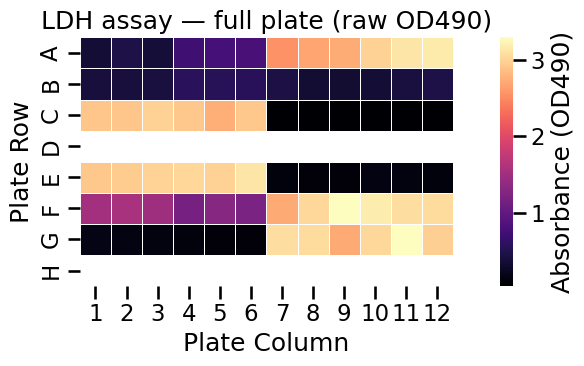

✅ Full-plate heatmap generated.


In [ ]:
# ==================================================
# Step 2.2: LOOK at your data (most important step!)
# ==================================================

assert "ldh_clean_df" in globals(), "Run Step 1 first (load the data)."
assert "ldh_plate_columns" in globals(), "Run Step 1 first (detect the plate columns)."

# Pivot to a plate-shaped table: rows = A–H, cols = 1–12
ldh_plate_matrix_df = (
    ldh_clean_df
    .set_index("Well")[ldh_plate_columns]
    .rename(columns=lambda x: int(str(x)))
    .apply(pd.to_numeric, errors="coerce")
)

# Sanity checks for the heatmap table
assert_dataframe(ldh_plate_matrix_df.reset_index(), name="ldh_plate_matrix_df(reset)", required_cols=set(["Well"] + list(range(1, 13))), min_rows=1)

plt.figure(figsize=(10, 4))
ax = sns.heatmap(
    ldh_plate_matrix_df,
    cmap="magma",
    square=True,
    cbar_kws={"label": CBAR_LABEL},
    linewidths=0.5,
    linecolor="white",
)
ax.set_title("LDH assay — full plate (raw OD490)")
ax.set_xlabel("Plate Column")
ax.set_ylabel("Plate Row")

# Save as PNG (overwrites safely if re-run)
plt.tight_layout()
plt.savefig("Assay2_ldh_full_plate_heatmap_raw_od490.png", dpi=300, bbox_inches="tight")
print(f"Saved: Assay2_ldh_full_plate_heatmap_raw_od490.png")
plt.show()

ok("Full-plate heatmap generated.")


## Step 2.3 — Convert the plate layout to “long” (tidy) format

The plate is a grid (A–H × 1–12). That’s great for pipetting, but for analysis it's easier to have **one row per well**:

| Well (1..96) | Sample | OD | Label |
|---|---|---:|---|

Most plotting libraries (and most statistics code) expect this “tidy” layout.
In the next step we will add the **Label** using a dictionary that matches the plate template

**What this code cell does (Step 2.3 — Convert the plate layout to “long” (tidy) format)**

- Converts the wide plate table into a long (tidy) format with one row per well measurement.
- Standardizes data types (row letter, column number, numeric OD values) and creates a 96‑well ID (e.g., A1, H12).
- Runs checks and shows a preview so downstream mapping is reliable.

In [ ]:
# ========================================
# Step 2.3: Convert to long-format table
# ========================================

assert "ldh_clean_df" in globals(), "Run Step 1 first (load the data)."
assert "ldh_plate_columns" in globals(), "Run Step 1 first (detect the plate columns)."

# Convert to long format: one row per well measurement
ldh_long_df = (
    ldh_clean_df
    .melt(
        id_vars=["Sample", "Well"],
        value_vars=ldh_plate_columns,
        var_name="Col",
        value_name="OD",
    )
    .copy()
)

# Standardize types + column names
ldh_long_df = (
    ldh_long_df
    .rename(columns={"Well": "Row"})
    .assign(
        Col=lambda d: d["Col"].astype(int),
        Row=lambda d: d["Row"].astype(str).str.upper(),
        OD=lambda d: pd.to_numeric(d["OD"], errors="coerce"),
    )
)

# 96‑well ID like A1, E12
ldh_long_df = ldh_long_df.assign(Well96=lambda d: d["Row"] + d["Col"].astype(str))

# Checks (important for downstream mapping)
assert_dataframe(ldh_long_df, name="ldh_long_df", required_cols={"Sample", "Row", "Col", "OD", "Well96"}, min_rows=96)

print("Long table rows:", len(ldh_long_df))
display(ldh_long_df.head())

ok("Long-format LDH table created (one row per well).")


Long table rows: 96


,Sample,Row,Col,OD,Well96
0,Media,A,1,0.3693,A1
1,Media,B,1,0.4093,B1
2,Media,C,1,2.9021,C1
3,Empty,D,1,NaN,D1
4,Cell_lysate,E,1,2.9215,E1


✅ Long-format LDH table created (one row per well).


## Step 2.4 — Map 96‑well positions to template labels

The next cell defines a dictionary:

- Key: **96‑well position** (e.g. `A1`, `B12`, `E3`)
- Value: the **template label** (e.g. `Unknown A1`, `Positive P2`, `Negative N1`)

Because each 12‑well sample was pipetted into **3 technical replicates**, the same label appears **3 times** in the media block and **3 times** in the lysate block.

After mapping, we will:

1. **Average technical replicates** for each label (separately for Media and Cell_lysate)
2. Compute **% LDH released** for each label (biological replicate)


**What this code cell does (Step 2.4 — Map 96‑well positions to template labels)**

- Defines the plate layout mapping (96‑well position → template label). Update this dictionary if your layout changes.
- Applies the mapping to label each well, infers sample type (Media vs Cell lysate), and extracts Condition + biological replicate number.
- Performs sanity checks and displays a preview to confirm the mapping worked.



In [ ]:
# ===========================================================================
# Step 2.4: Plate layout dictionary (maps each 96‑well position to a label)
# ===========================================================================

assert "ldh_long_df" in globals(), "Run Step 3 first (create ldh_long_df)."

# IMPORTANT:
# - Key: 96‑well position (e.g. A1, B12)
# - Value: template label (e.g. Unknown A1, Positive P2, Negative N1)
# If your plate layout changes, this dictionary is the ONE place to update.
WELL96_TO_LABEL = {
    # Row A
    "A1": "Unknown A1",
    "A2": "Unknown A1",
    "A3": "Unknown A1",
    "A4": "Unknown A2",
    "A5": "Unknown A2",
    "A6": "Unknown A2",
    "A7": "Unknown B1",
    "A8": "Unknown B1",
    "A9": "Unknown B1",
    "A10": "Unknown B2",
    "A11": "Unknown B2",
    "A12": "Unknown B2",

    # Row B
    "B1": "Unknown C1",
    "B2": "Unknown C1",
    "B3": "Unknown C1",
    "B4": "Unknown C2",
    "B5": "Unknown C2",
    "B6": "Unknown C2",
    "B7": "Unknown D1",
    "B8": "Unknown D1",
    "B9": "Unknown D1",
    "B10": "Unknown D2",
    "B11": "Unknown D2",
    "B12": "Unknown D2",

    # Row C
    "C1": "Positive P1",
    "C2": "Positive P1",
    "C3": "Positive P1",
    "C4": "Positive P2",
    "C5": "Positive P2",
    "C6": "Positive P2",
    "C7": "Negative N1",
    "C8": "Negative N1",
    "C9": "Negative N1",
    "C10": "Negative N2",
    "C11": "Negative N2",
    "C12": "Negative N2",

    # Row E
    "E1": "Unknown A1",
    "E2": "Unknown A1",
    "E3": "Unknown A1",
    "E4": "Unknown A2",
    "E5": "Unknown A2",
    "E6": "Unknown A2",
    "E7": "Unknown B1",
    "E8": "Unknown B1",
    "E9": "Unknown B1",
    "E10": "Unknown B2",
    "E11": "Unknown B2",
    "E12": "Unknown B2",

    # Row F
    "F1": "Unknown C1",
    "F2": "Unknown C1",
    "F3": "Unknown C1",
    "F4": "Unknown C2",
    "F5": "Unknown C2",
    "F6": "Unknown C2",
    "F7": "Unknown D1",
    "F8": "Unknown D1",
    "F9": "Unknown D1",
    "F10": "Unknown D2",
    "F11": "Unknown D2",
    "F12": "Unknown D2",

    # Row G
    "G1": "Positive P1",
    "G2": "Positive P1",
    "G3": "Positive P1",
    "G4": "Positive P2",
    "G5": "Positive P2",
    "G6": "Positive P2",
    "G7": "Negative N1",
    "G8": "Negative N1",
    "G9": "Negative N1",
    "G10": "Negative N2",
    "G11": "Negative N2",
    "G12": "Negative N2",
}

# -------------------------
# Apply mapping to create a labeled well-level table (technical replicates)
# -------------------------
ldh_labeled_df = ldh_long_df.assign(Label=ldh_long_df["Well96"].map(WELL96_TO_LABEL))

# Drop wells that are not part of the template (e.g., unused rows like D/H)
ldh_labeled_df = ldh_labeled_df.dropna(subset=["Label"]).copy()

# Infer sample type from the 'Sample' column
sample_lower = ldh_labeled_df["Sample"].astype("string").str.lower()

is_media = sample_lower.str.contains("media", na=False)
is_lysate = sample_lower.str.contains("lysate|cell", na=False)

sample_type = pd.Series(pd.NA, index=ldh_labeled_df.index, dtype="string")
sample_type.loc[is_media] = "Media"
sample_type.loc[~is_media & is_lysate] = "Cell_lysate"

ldh_labeled_df = ldh_labeled_df.assign(SampleType=sample_type)

# Derive Condition and biological replicate number from the label
# Example: "Unknown A1" -> Condition="Unknown A", BioRep=1
extract = ldh_labeled_df["Label"].astype(str).str.extract(r"^(?P<Condition>.*?)(?P<BioRep>\d+)$")
ldh_labeled_df = ldh_labeled_df.assign(
    Condition=extract["Condition"].astype(str).str.strip().replace(CONTROL_RENAME),
    BioRep=pd.to_numeric(extract["BioRep"], errors="coerce"),
)

# Sanity checks
assert_dataframe(ldh_labeled_df, name="ldh_labeled_df", required_cols={"Sample", "SampleType", "Row", "Col", "OD", "Well96", "Label", "Condition", "BioRep"}, min_rows=1)
assert ldh_labeled_df["SampleType"].notna().all(), (
    "Could not infer SampleType for some rows. Check the 'Sample' column values (expected to contain 'media' or 'lysate/cell')."
)
assert ldh_labeled_df["BioRep"].notna().all(), "BioRep extraction failed for some labels (expected label ending in a digit, e.g. 'Unknown A1')."

# Quick QC: do we have both media and lysate?
present_types = sorted(ldh_labeled_df["SampleType"].unique().tolist())
print("Sample types detected:", present_types)
display(ldh_labeled_df.head(10))

ok("Well-to-label mapping applied (ldh_labeled_df created).")


Sample types detected: ['Cell_lysate', 'Media']


,Sample,Row,Col,OD,Well96,Label,SampleType,Condition,BioRep
0,Media,A,1,0.3693,A1,Unknown A1,Media,Unknown A,1
1,Media,B,1,0.4093,B1,Unknown C1,Media,Unknown C,1
2,Media,C,1,2.9021,C1,Positive P1,Media,Positive Control,1
4,Cell_lysate,E,1,2.9215,E1,Unknown A1,Cell_lysate,Unknown A,1
5,Cell_lysate,F,1,1.5276,F1,Unknown C1,Cell_lysate,Unknown C,1
6,Cell_lysate,G,1,0.1599,G1,Positive P1,Cell_lysate,Positive Control,1
8,Media,A,2,0.4591,A2,Unknown A1,Media,Unknown A,1
9,Media,B,2,0.4076,B2,Unknown C1,Media,Unknown C,1
10,Media,C,2,2.9023,C2,Positive P1,Media,Positive Control,1
12,Cell_lysate,E,2,2.9450,E2,Unknown A1,Cell_lysate,Unknown A,1


✅ Well-to-label mapping applied (ldh_labeled_df created).


## Step 2.5 — Averaging the technical replicate

Each 12-well sample (e.g., **Unknown A1**) was pipetted into the 96-well plate as **3 technical replicates** (aliquots).
Before calculating cytotoxicity, we first compute the **technical mean OD490** separately for:

- **Media** (released LDH)
- **Cell_lysate** (intracellular/total LDH)

This reduces noise from pipetting/reading variation and gives **one Media value + one Lysate value per biological replicate label** (A1, A2, …).

The plots below show these technical means per biological replicate and help you spot obvious problems:
- missing wells (wrong N_tech),
- unusually high/low signals,
- large differences between biological replicates (A1 vs A2).

**What this code cell does (Step 2.5 — Averaging the technical replicate)**

- Averages technical replicates within each condition/biological replicate for Media and Cell lysate separately.
- Pivots results so each biological replicate has paired values (OD_media and OD_cells) in the same row (`ldh_paired_df`).
- Shows a QC plot of raw media OD values to check replicate consistency.

,Label,Condition,BioRep,SampleType,N_tech,Mean_OD,SD_OD
0,Negative N1,Negative Control,1,Cell_lysate,3,2.946600,0.197875
1,Negative N1,Negative Control,1,Media,3,0.046767,0.000306
2,Negative N2,Negative Control,2,Cell_lysate,3,3.096167,0.171152
3,Negative N2,Negative Control,2,Media,3,0.046067,0.000404
4,Positive P1,Positive Control,1,Cell_lysate,3,0.152567,0.011511
5,Positive P1,Positive Control,1,Media,3,2.928533,0.045611
6,Positive P2,Positive Control,2,Cell_lysate,3,0.112733,0.010391
7,Positive P2,Positive Control,2,Media,3,2.859633,0.101148
8,Unknown A1,Unknown A,1,Cell_lysate,3,2.953700,0.037318
9,Unknown A1,Unknown A,1,Media,3,0.403267,0.048730


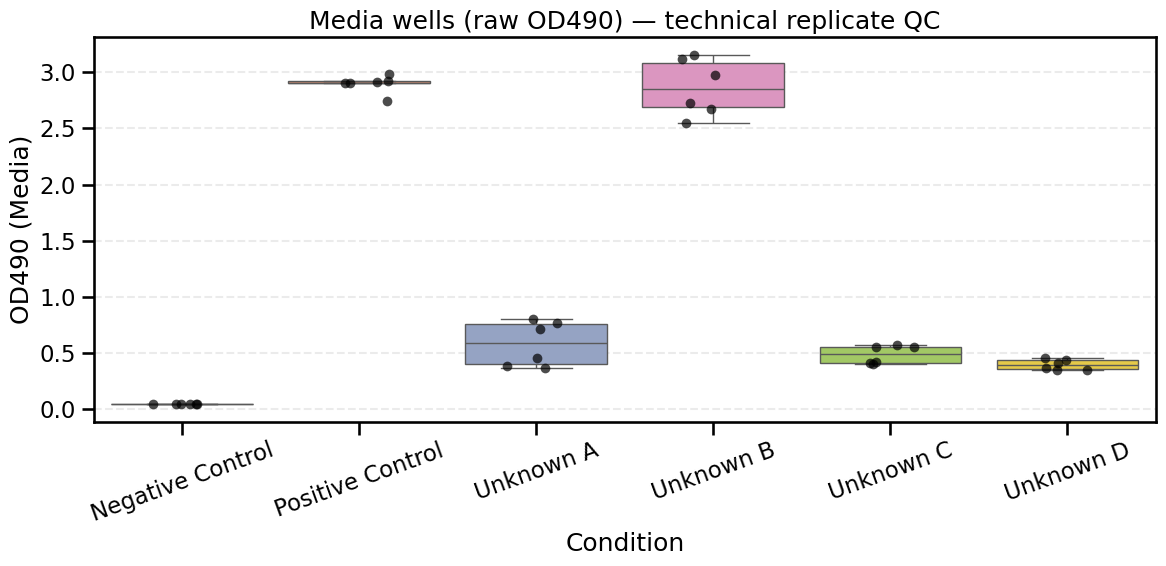

✅ Technical replicates averaged (ldh_paired_df created) + QC plot shown.


In [ ]:
# ==================================================================
# Step 2.5: Average technical replicates (per biological replicate)
# ==================================================================

assert "ldh_labeled_df" in globals(), "Run Step 4 first (create ldh_labeled_df)."

# Keep only the two sample fractions we need
ldh_analysis_input_df = ldh_labeled_df[ldh_labeled_df["SampleType"].isin(["Media", "Cell_lysate"])].copy()
assert_dataframe(ldh_analysis_input_df, name="ldh_analysis_input_df", min_rows=1)

# Average technical replicates within each label (A1/A2...) separately for Media vs Cell_lysate
ldh_technical_summary_df = (
    ldh_analysis_input_df
    .groupby(["Label", "Condition", "BioRep", "SampleType"])["OD"]
    .agg(N_tech="count", Mean_OD="mean", SD_OD="std")
    .reset_index()
)
assert_dataframe(ldh_technical_summary_df, name="ldh_technical_summary_df", required_cols={"Label", "Condition", "BioRep", "SampleType", "N_tech", "Mean_OD", "SD_OD"}, min_rows=1)

display(ldh_technical_summary_df.head(12))

# Pivot to one row per biological replicate with paired media + lysate means
ldh_paired_mean_od_df = (
    ldh_technical_summary_df
    .pivot_table(index=["Label", "Condition", "BioRep"], columns="SampleType", values="Mean_OD", aggfunc="first")
    .reset_index()
    .rename_axis(None, axis=1)
    .rename(columns={"Media": "OD_media", "Cell_lysate": "OD_cells"})
)

ldh_paired_counts_df = (
    ldh_technical_summary_df
    .pivot_table(index=["Label", "Condition", "BioRep"], columns="SampleType", values="N_tech", aggfunc="first")
    .reset_index()
    .rename_axis(None, axis=1)
    .rename(columns={"Media": "N_media_tech", "Cell_lysate": "N_cells_tech"})
)

ldh_paired_df = (
    ldh_paired_mean_od_df
    .merge(ldh_paired_counts_df, on=["Label", "Condition", "BioRep"], how="left")
)

# Sanity checks: required columns for downstream steps
required_paired_cols = {"Label", "Condition", "BioRep", "OD_media", "OD_cells", "N_media_tech", "N_cells_tech"}
assert_dataframe(ldh_paired_df, name="ldh_paired_df", required_cols=required_paired_cols, min_rows=1)

# -------------------------
# QC plot: raw OD in Media (technical replicates)
# -------------------------
conditions_present = ldh_paired_df["Condition"].dropna().unique().tolist()
ldh_condition_order = [c for c in PLOT_ORDER_DEFAULT if c in conditions_present] + sorted(
    [c for c in conditions_present if c not in PLOT_ORDER_DEFAULT]
)

plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    data=ldh_analysis_input_df[ldh_analysis_input_df["SampleType"] == "Media"],
    x="Condition",
    y="OD",
    order=ldh_condition_order,
    hue="Condition",
    legend=False,
    palette=COLOR_MAP,
    showfliers=False,
)
sns.stripplot(
    data=ldh_analysis_input_df[ldh_analysis_input_df["SampleType"] == "Media"],
    x="Condition",
    y="OD",
    order=ldh_condition_order,
    color="black",
    size=7,
    jitter=0.18,
    alpha=0.7,
)
ax.set_title("Media wells (raw OD490) — technical replicate QC")
ax.set_xlabel("Condition")
ax.set_ylabel("OD490 (Media)")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.25, linestyle="--")
plt.tight_layout()
plt.show()

ok("Technical replicates averaged (ldh_paired_df created) + QC plot shown.")


## Step 2.6 — Calculate % LDH released

Now that each biological replicate label (e.g., **Unknown A1**) has:
- one technical-mean **Media** value (released LDH), and
- one technical-mean **Cell_lysate** value (intracellular LDH),

we compute the cytotoxicity metric:

$$
\%\,\mathrm{LDH\ released} = \frac{M}{M+C}\times 100
$$

where:
- \(M\) = technical-mean OD490 in **Media**
- \(C\) = technical-mean OD490 in **Cell lysate**

This produces **one % value per biological replicate label** (A1, A2, …).


**What this code cell does (Step 2.6 — Calculate % LDH released)**

- Calculates % LDH released for each biological replicate: OD_media / (OD_media + OD_cells) × 100.
- Builds a plotting order (controls first, then unknowns) based on conditions present in the data.
- Summarises biological replicates per condition (N, mean, SD) and displays a clean table.


In [ ]:
# ==============================================================
# Step 2.6: Calculate % LDH released (per biological replicate)
# ==============================================================

assert "ldh_paired_df" in globals(), "Run Step 5 first (create ldh_paired_df)."

# Compute percent LDH released WITHOUT modifying ldh_paired_df in place
ldh_percent_df = ldh_paired_df.assign(
    Total=lambda d: d["OD_media"] + d["OD_cells"],
    Percent_LDH_released=lambda d: np.where(
        (d["OD_media"].notna()) & (d["OD_cells"].notna()) & ((d["OD_media"] + d["OD_cells"]) > 0),
        (d["OD_media"] / (d["OD_media"] + d["OD_cells"])) * 100,
        np.nan,
    ),
)

assert_dataframe(
    ldh_percent_df,
    name="ldh_percent_df",
    required_cols={"Condition", "BioRep", "OD_media", "OD_cells", "Total", "Percent_LDH_released"},
    min_rows=1,
)

# Plot/save order used downstream: include only what's present, but keep the same default order idea
conditions_present = ldh_percent_df["Condition"].dropna().unique().tolist()
ldh_condition_order = [c for c in PLOT_ORDER_DEFAULT if c in conditions_present] + sorted(
    [c for c in conditions_present if c not in PLOT_ORDER_DEFAULT]
)

# Condition-level summary (biological replicates, typically n=2)
ldh_condition_summary_df = (
    ldh_percent_df.dropna(subset=["Percent_LDH_released"])
    .groupby("Condition")["Percent_LDH_released"]
    .agg(N_biorep="count", Mean_percent="mean", SD_percent="std")
    .reset_index()
)

assert_dataframe(ldh_condition_summary_df, name="ldh_condition_summary_df", required_cols={"Condition", "N_biorep", "Mean_percent", "SD_percent"}, min_rows=1)

# Display a clean summary table
ldh_summary_display_df = ldh_condition_summary_df.copy()
ldh_summary_display_df["Mean ± SD"] = ldh_summary_display_df.apply(
    lambda r: f'{r["Mean_percent"]:.1f} ± {r["SD_percent"]:.1f}' if not np.isnan(r["SD_percent"]) else f'{r["Mean_percent"]:.1f} ± NA',
    axis=1,
)

display(ldh_summary_display_df[["Condition", "N_biorep", "Mean_percent", "SD_percent", "Mean ± SD"]])

ok("Percent LDH released computed (ldh_percent_df + ldh_condition_summary_df created).")


,Condition,N_biorep,Mean_percent,SD_percent,Mean ± SD
0,Negative Control,2,1.514196,0.068091,1.5 ± 0.1
1,Positive Control,2,95.627796,0.819524,95.6 ± 0.8
2,Unknown A,2,16.054607,5.715938,16.1 ± 5.7
3,Unknown B,2,95.739889,0.257279,95.7 ± 0.3
4,Unknown C,2,26.409759,7.159957,26.4 ± 7.2
5,Unknown D,2,11.521271,0.382350,11.5 ± 0.4


✅ Percent LDH released computed (ldh_percent_df + ldh_condition_summary_df created).


## Step 2.7 — Plot % LDH released

This plot is the **main LDH assay result** and creates a condition-level summary (mean ± SD across biological replicates)

- Each dot is one **biological replicate** (e.g., **Unknown A1** and **Unknown A2**, etc).
- The black marker with error bars shows the **mean ± SD across biological replicates**.
- The **boxplot** summarizes the distribution across **biological replicates**.


**What this code cell does (Step 2.7 — Plot % LDH released)**

- Creates the main reportable plot: individual biological replicates (dots) plus mean ± SD for each condition.
- Applies clear formatting (axis limits, labels, ordering) and optionally labels mean values.
- Saves the final figure as a PNG and shows it in the notebook.


Saved: Assay2_ldh_final_boxplot.png


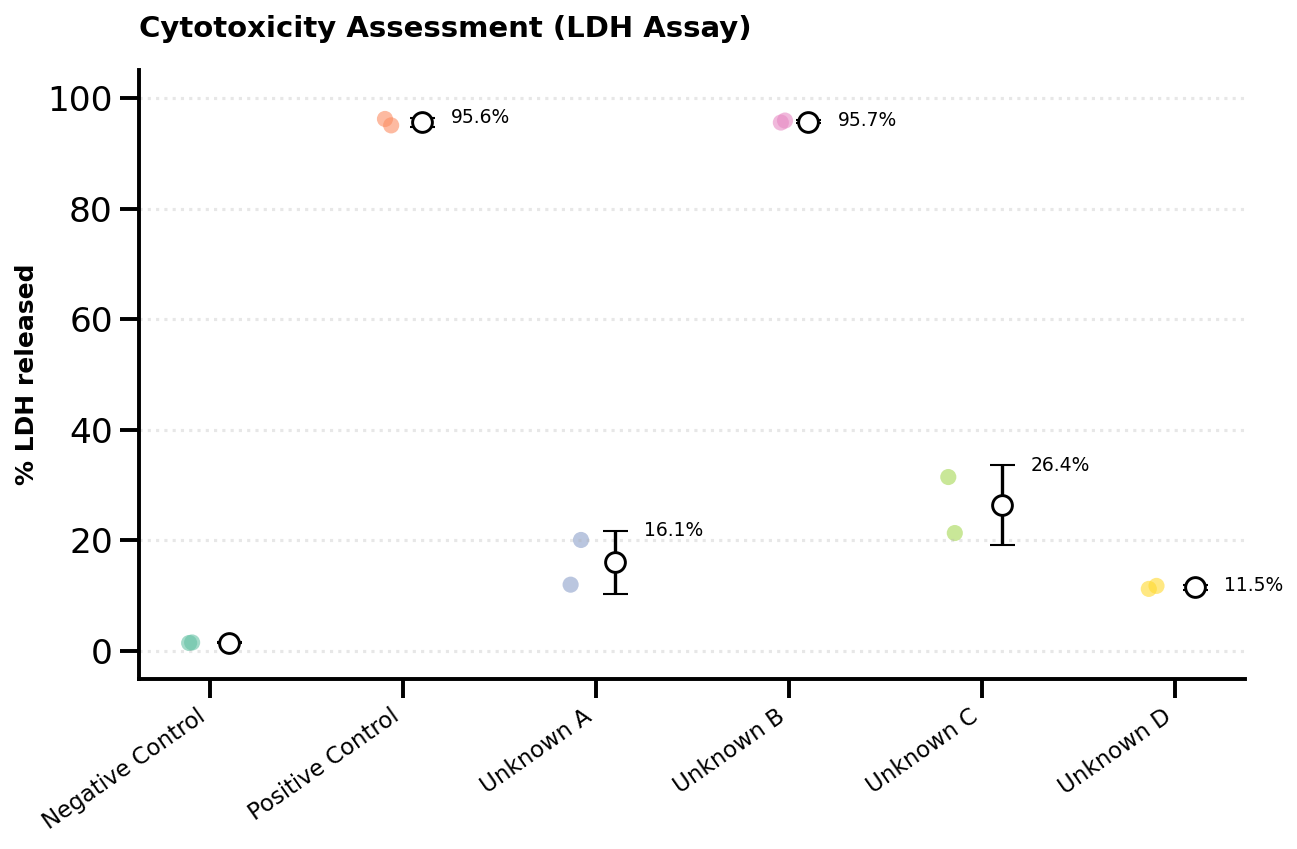

✅ Final LDH % release plot generated.


In [ ]:
# ==================================================
# Step 2.7: Plot the %LDH release (dots + mean ± SD)
# ==================================================

assert "ldh_percent_df" in globals(), "Run Step 6 first (create ldh_percent_df)."
assert "ldh_condition_order" in globals(), "Run Step 6 first (compute ldh_condition_order)."

ldh_plot_df = ldh_percent_df.dropna(subset=["Percent_LDH_released"]).copy()
assert_dataframe(ldh_plot_df, name="ldh_plot_df", required_cols={"Condition", "Percent_LDH_released"}, min_rows=1)

# Keep only the conditions in our chosen plotting order
ldh_plot_order = [c for c in ldh_condition_order if c in ldh_plot_df["Condition"].unique()]

# Summary table computed from the same values that appear as dots
ldh_plot_summary_df = (
    ldh_plot_df.groupby("Condition")["Percent_LDH_released"]
    .agg(["count", "mean", "std"])
    .reindex(ldh_plot_order)
)

fig, ax = plt.subplots(figsize=(9, 6), dpi=150)
rng = np.random.default_rng(0)

for i, cond in enumerate(ldh_plot_order):
    vals = ldh_plot_df.loc[ldh_plot_df["Condition"] == cond, "Percent_LDH_released"].to_numpy()
    mean_val = ldh_plot_summary_df.loc[cond, "mean"]
    sd_val = ldh_plot_summary_df.loc[cond, "std"]

    color = COLOR_MAP.get(cond, "gray")

    # Individual biological replicates (jittered slightly)
    x_jitter = rng.normal(i - 0.1, 0.06, size=len(vals))
    ax.scatter(x_jitter, vals, alpha=0.6, s=60, color=color, edgecolor="none", zorder=1)

    # Mean ± SD (offset slightly to the right)
    ax.errorbar(
        i + 0.1,
        mean_val,
        yerr=sd_val,
        fmt="none",
        ecolor="black",
        elinewidth=1.6,
        capsize=6,
        zorder=2,
    )
    ax.scatter(
        i + 0.1,
        mean_val,
        marker="o",
        s=90,
        linewidth=1.4,
        edgecolor="black",
        facecolor="white",
        zorder=3,
    )

    # Optional: label means (only if there is a meaningful value)
    if mean_val > 5:
        ax.text(
            i + 0.25,
            mean_val + (sd_val if not np.isnan(sd_val) else 0),
            f"{mean_val:.1f}%",
            ha="left",
            va="center",
            fontsize=9,
        )

# Formatting
ax.set_ylim(-5, 105)
ax.set_ylabel("% LDH released", fontsize=12, fontweight="bold")
ax.set_xticks(range(len(ldh_plot_order)))
ax.set_xticklabels(ldh_plot_order, rotation=35, ha="right", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle=":", alpha=0.3)
ax.set_title(
    "Cytotoxicity Assessment (LDH Assay)",
    fontsize=14,
    fontweight="bold",
    pad=16,
    loc="left",
)

# Save as PNG (overwrites safely if re-run)
plt.tight_layout()
plt.savefig("Assay2_ldh_final_boxplot.png", dpi=300, bbox_inches="tight")
print(f"Saved: Assay2_ldh_final_boxplot.png")

plt.show()

ok("Final LDH % release plot generated.")


## Step 2.8 — Export the LDH summary table (CSV + Excel)

This cell exports the same **one-row-per-condition** summary table in two formats:

- **CSV** (easy to open anywhere / easy to upload)
- **Excel (.xlsx)** (nice formatting and convenient for reports)

Both files contain: *n (biological replicates), mean % LDH released, SD, and a “Mean ± SD” column*.


**What this code cell does (Step 2.8 — Export the LDH summary table (CSV + Excel))**

- Formats the condition summary table in the same order used for plotting (controls first).
- Adds a human-readable “Mean ± SD” column for reporting.
- Exports the summary to an Excel file (`assay2_ldh_results.xlsx`).


In [ ]:
# ====================================
# Step 2.8: Save summary table (Excel)
# ====================================

assert "ldh_condition_summary_df" in globals(), "Run Step 6 first (create ldh_condition_summary_df)."
assert "ldh_condition_order" in globals(), "Run Step 6 first (compute ldh_condition_order)."

ldh_out_xlsx = "assay2_ldh_results.xlsx"

# Use the same condition order as in plots (controls first, then unknowns)
ldh_report_df = ldh_condition_summary_df.copy()
ldh_report_df["Condition"] = pd.Categorical(ldh_report_df["Condition"], categories=ldh_condition_order, ordered=True)
ldh_report_df = ldh_report_df.sort_values("Condition").reset_index(drop=True)

# Add formatted mean ± SD string
ldh_report_df["Mean ± SD"] = ldh_report_df.apply(
    lambda r: f'{r["Mean_percent"]:.2f} ± {r["SD_percent"]:.2f}'
    if not np.isnan(r["SD_percent"])
    else f'{r["Mean_percent"]:.2f} ± NA',
    axis=1
)

# Save Excel (overwrites safely if re-run)
with pd.ExcelWriter(ldh_out_xlsx, engine="openpyxl") as writer:
    ldh_report_df.to_excel(writer, sheet_name="LDH summary", index=False)
assert os.path.exists(ldh_out_xlsx), f"Failed to create {ldh_out_xlsx}"
print(f"Saved: {ldh_out_xlsx}")


Saved: assay2_ldh_results.xlsx


## Assay 2 - Interpretation

Look at the data in the summary table and the plots.

- Do **Negative** and **Positive** controls separate as expected?
- Which unknown condition(s) show **higher % release** (more cytotoxicity)?
- Are there any conditions with **missing replicates** (n < 2) or missing technical replicates (n < 3)?
- Which **unknown** looks most like the **Positive Control**?
- Which **unknown** looks most like the **Negative Control**?
- If one condition has a very large SD, what might explain it (pipetting, bubbles, wrong wells, incomplete lysis)?

### Write down your conclusions </span> ✍️🧑‍💻

# Assay 3: Griess assay (nitrite/NO₂⁻)

In this assay, we measure how immune cells react to a compound with a spectrophotometer. Here, you can determine if your compound is inflammatory to microglia. There are three important things to learn from this one.

 - What is the biology and chemistry of our assay? What kind of data are we measuring?
 - How can we make or experiments reproducible and robust? Let's talk about blanks, replicates, and standard curves
 - The fun part, what are our results? How can we learn about our compound?

Now, here is a neat little emoji-based learning-system I invented

 - ✅ Your code ran successfully. There should be one of these after every cell. Every single time, the most common error is forgetting to run a cell.
 - ❌ Something went wrong and hopefully it tells you what. These only check stuff that I anticipated would fail. Things can still very much fail for other reasons.
 - 🧱 Parts of this code are a bit dense and boring plotting boilerplate. I added bricks so you know that you can skim that code.
 - 🌟 These are questions or small tasks. These are the important parts of this section and where all the fun happens.

Both the laboratory techniques and the data science is something you are going to use again and again, so don't panic if it seems complicated here.

## Step 3.1 Loading the data

Here, we are going to load your data from the spectrophotometer and check that it looks alright. I assume you copy-pasted it correctly into the Excel template. If you did not, **everything breaks fantastically** and I cannot save you. Check the shape of the table with `assert` and look at the heatmap to see if it matches your expectations.

What values do the controls have? LPS? Should they be high or low. The smart student can eyeball the heatmap and finish the exercise without running any code (don't do that though).


**What this code cell does (Step 3.1 — Loading the data)**

- Sets the file path to the Assay 3 Excel sheet.
- Checks that the file exists (so you catch typos in the path early).
- Reads the plate data into a pandas DataFrame (`raw_data`) and uses the first column as row labels.
- Forces all values to be numeric and checks for missing values.
- Stops the notebook with a clear error message if something looks wrong, otherwise confirms the data loaded correctly.

In [ ]:
# ===================================
# Step 3.1: Load the data with pandas
# ===================================

# 🌟 Make sure this matches the path to your file
PATH = "/content/Assay_3_Griess_sample_data.xlsx"


# --- Validation ---

# here I assert that the file exsists because I expect you can type
assert Path(PATH).exists(), f"File not found: {PATH} ❌"

# --- Load data ---
raw_data = pd.read_excel(
    PATH,
    sheet_name="Sheet1",
    usecols=range(13),  # First column = labels, then 12 data columns
    index_col=0,
    nrows=4,
)

# --- Validate contents ---
raw_data = raw_data.apply(pd.to_numeric, errors="raise")


assert_dataframe(raw_data, name="raw_data", min_rows=1)
# Again, I assert that there are no missing values
assert raw_data.notnull().all().all(), "Missing values found in data ❌"

ok("Data loaded successfully!")

✅ Data loaded successfully!


## Step 3.2 - Verify the shape and labels of the data

**What this code cell does (Step 3.2 — Verify shape and labels)**

- Defines the expected plate dimensions for this dataset (here: **4 rows × 12 columns**).
- Verifies that the loaded DataFrame matches those dimensions.
- Prints the shape and displays the data so you can visually confirm the layout before continuing.

In [ ]:
# ======================================================
# Step 3.2: Verify the data shape (4 rows × 12 columns)
# ======================================================

# 🌟 Edit these to match the dimensions of your plate
# What would happen if they were wrong?
EXPECTED_ROWS = 4
EXPECTED_COLS = 12

# --- Validation ---
assert raw_data.shape == (EXPECTED_ROWS, EXPECTED_COLS), (
    f"Expected {EXPECTED_ROWS}×{EXPECTED_COLS}, got {raw_data.shape} ❌"
)

print(f"Data shape: {raw_data.shape[0]} rows × {raw_data.shape[1]} columns")
display(raw_data)
ok("Data shape is correct!")

Data shape: 4 rows × 12 columns


,Control 1,Control 2,Control 3,Unknown 1,Unknown 2,Unknown 3,LPS 1,LPS 2,LPS 3,UNK + LPS 1,UNK +LPS 2,UNK + LPS 3
Compounds,,,,,,,,,,,,
Std Curve 1,0.2542,0.1641,0.0853,0.0672,0.0548,0.0526,0.0485,0.0464,0.0398,0.0464,0.0466,0.0470
Std Curve 2,0.2713,0.1567,0.0870,0.0678,0.0551,0.0487,0.0473,0.0463,0.0629,0.0460,0.0460,0.0463
Sample 1,0.0944,0.0461,0.0471,0.0661,0.0489,1.6927,0.5821,0.6123,0.5381,1.5550,0.0524,0.1555
Sample 2,0.4132,0.0654,0.1082,0.0508,0.0752,0.1730,0.5160,0.3852,0.5175,0.5430,0.0489,0.1570


✅ Data shape is correct!


## Step 3.3 - Visualizing the war data as a heatmap

**What this code cell does (Step 3.3 — Heatmap of raw OD values)**

- Lets you set plot labels (title, axis labels, colorbar label) and choose a colormap.
- Plots the raw plate values as a heatmap with numbers in each well (useful for spotting edge effects, pipetting errors, or outliers).
- Shows the figure so you can quickly sanity-check the raw readout before processing.


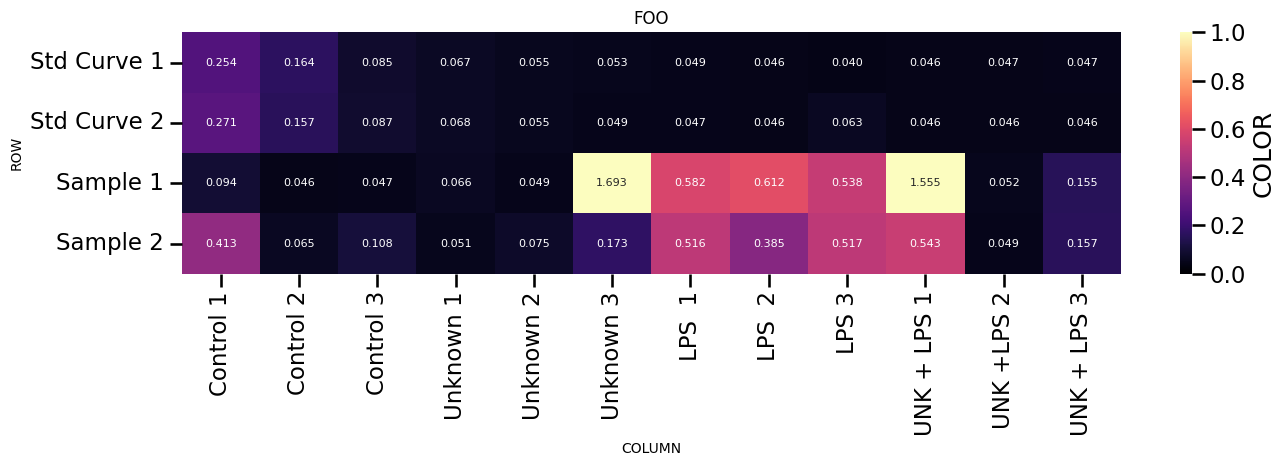

✅ Heatmap generated!


In [ ]:
# =========================================
# Step 3.3: Visualize raw data as a heatmap
# =========================================

# 🌟 Edit these labels for your heatmap
# What does each mean in your actual experiment?
TITLE = "FOO"
COLORBAR_LABEL = "COLOR"
X_LABEL = "COLUMN"
Y_LABEL = "ROW"

# 🌟 TRY DIFFERENT COLORMAPS: 'viridis', 'mako', 'inferno', 'magma', 'cividis'
# I think 'mako' is neat.
# You can try searching online for 'viridis' to learn why these are cooler than you think
COLORMAP = "magma"

# --- Validation ---
assert TITLE, "Please set a title for your heatmap ❌"

# --- Create heatmap ---
# You can also change the font size if it looks weird
plt.figure(figsize=(14, 5))
sns.heatmap(
    raw_data,
    cmap=COLORMAP,
    annot=True,
    fmt=".3f",
    vmin=0,
    vmax=1,
    cbar_kws={"label": COLORBAR_LABEL},
    annot_kws={"size": 8},
)
plt.xlabel(X_LABEL, fontsize=10)
plt.ylabel(Y_LABEL, fontsize=10)
plt.title(TITLE, fontsize=12)
plt.tight_layout()
plt.show()

ok("Heatmap generated!")

## Step 3.4 -  Splitting data into standard curve and samples, then background-correct

**What this code cell does (Step 3.4 — Split standard curve vs samples + background correction)**

- Creates human-readable column names for:
  - the **standard curve** wells (`S1`–`S12`), and
  - the **sample** wells (Control / Unknown / LPS / UNK+LPS replicates).
- Splits `raw_data` into two DataFrames: `std_curve` (rows 1–2) and `samples` (rows 3–4).
- Estimates the **blank/background** signal using the water/zero-concentration wells (`S9`–`S12`).
- Subtracts that blank from both the standard curve and sample wells to produce background-corrected tables.

In [ ]:
# ===========================================================================
# Step 3.4: Split data into standard curve and samples, then background-correct
# 🧱🧱🧱 We slice your plate into two different tables, curve and samples
# =============================================================================

# --- Define column labels ---
STD_COLS = [f"S{i}" for i in range(1, 13)]
SAMPLE_COLS = (
    [f"Control {i}" for i in (1, 2, 3)]
    + [f"Unknown {i}" for i in (1, 2, 3)]
    + [f"LPS {i}" for i in (1, 2, 3)]
    + [f"UNK+LPS {i}" for i in (1, 2, 3)]
)

# --- Sanity checks (shared with the LDH notebook) ---
assert_nonempty_list(STD_COLS, name="STD_COLS")
assert_nonempty_list(SAMPLE_COLS, name="SAMPLE_COLS")

# --- Split into two DataFrames (creates copies, not views) ---
std_curve = raw_data.iloc[0:2].copy()
std_curve.columns = STD_COLS
std_curve.index = ["Std Curve 1", "Std Curve 2"]

samples = raw_data.iloc[2:4].copy()
samples.columns = SAMPLE_COLS
samples.index = ["Sample 1", "Sample 2"]

# --- Validation ---
assert std_curve.shape == (2, 12), "Standard curve shape error ❌"
assert samples.shape == (2, 12), "Samples shape error ❌"

# ========================
# 🧱🧱🧱 Phew, that was a lot of Pandas slicing
# ========================


# --- Calculate blank from standard curve columns S9-S12 (zero concentration) ---
# 🌟 We are calculating the mean of the water-only wells here. Why do we do that?
# Should they have any signal?
BLANK_COLS = ["S9", "S10", "S11", "S12"]
assert_nonempty_list(BLANK_COLS, name="BLANK_COLS")
blank_value = float(std_curve[BLANK_COLS].values.mean())

# --- Background correction: subtract blank from all values ---
# 🌟 And now we subtract that mean from everything. Why might we want to do that?
std_curve_corrected = std_curve - blank_value
samples_corrected = samples - blank_value

print(f"Blank value (mean of S9-S12): {blank_value:.4f}")
ok("Data split and background-corrected!")

Blank value (mean of S9-S12): 0.0476
✅ Data split and background-corrected!


## Step 3.5  Handling negative values after background correction

**What this code cell does (Step 3.5 — Handle negative values after blank subtraction)**

- Checks whether any values became negative after background correction (this can happen when signal is close to the blank level).
- Gives you the option to **clip** negative values to zero (`CLIP_NEGATIVES = True`) or keep them as-is.
- Creates the “final” corrected tables (`std_curve_final`, `samples_final`) that will be used in the next steps.


In [ ]:
# =========================
# Step 3.5: Handle negative values after background correction
# =========================


# After subtracting the blank, some values may be slightly negative due to noise.
# 🌟 Discuss, do negative values make sense? Why/why not?

has_negatives = (std_curve_corrected < 0).any().any() or (
    samples_corrected < 0
).any().any()
if has_negatives:
    print("⚠️  Warning: Some values are negative after background correction")
    print("    This can happen when signal is close to blank level")


# 🌟 You can change this to True to clip negatives to zero
# Do you think we should clip them to zero?
CLIP_NEGATIVES = False


if CLIP_NEGATIVES:
    std_curve_final = std_curve_corrected.clip(lower=0)
    samples_final = samples_corrected.clip(lower=0)
else:
    std_curve_final = std_curve_corrected.copy()
    samples_final = samples_corrected.copy()


print(f"Negative values clipped to zero: {CLIP_NEGATIVES}")
display(samples_final)
ok("Data ready for analysis!")

⚠️  Warning: Some values are negative after background correction
    This can happen when signal is close to blank level
Negative values clipped to zero: False


,Control 1,Control 2,Control 3,Unknown 1,Unknown 2,Unknown 3,LPS 1,LPS 2,LPS 3,UNK+LPS 1,UNK+LPS 2,UNK+LPS 3
Sample 1,0.046775,-0.001525,-0.000525,0.018475,0.001275,1.645075,0.534475,0.564675,0.490475,1.507375,0.004775,0.107875
Sample 2,0.365575,0.017775,0.060575,0.003175,0.027575,0.125375,0.468375,0.337575,0.469875,0.495375,0.001275,0.109375


✅ Data ready for analysis!


## Step 3.6 - Calculating mean OD for each standard curve concentration

**What this code cell does (Step 3.6 — Standard curve means)**

- Defines the known nitrite concentrations for the standard curve (µM).
- Computes the mean OD for each concentration by averaging the two standard-curve replicate rows (using `S1`–`S8`).
- Builds a tidy summary table (`std_curve_summary`) with concentration vs mean OD, which is what we fit the curve to.

In [ ]:
# =========================
# Step 3.6: Calculate mean OD for each standard curve concentration
# =========================
# The standard curve has known nitrite concentrations in columns S1-S8.
# Columns S9-S12 contain blanks (0 µM) and were used for background correction.

# Known nitrite concentrations (µM) for S1-S8 (two-fold dilutions starting at 100)
NITRITE_CONCENTRATIONS = [100, 50, 25, 12.5, 6.25, 3.13, 1.56, 0]

# --- Calculate mean OD across the two replicate rows (S1-S8 only) ---
std_curve_data_cols = [f"S{i}" for i in range(1, 9)]  # S1-S8
std_curve_means = std_curve_final[std_curve_data_cols].mean(axis=0)

# --- Create summary DataFrame ---
std_curve_summary = pd.DataFrame(
    {"Nitrite_uM": NITRITE_CONCENTRATIONS, "Mean_OD": std_curve_means.values}
)

# --- Validation ---
assert len(std_curve_summary) == 8, "Expected 8 standard curve points ❌"

print("Standard curve summary:")
display(std_curve_summary.round(4))
ok("Standard curve means calculated!")
print("🌟 Check your intuition, if concentration go up, then OD should go?...")

Standard curve summary:


,Nitrite_uM,Mean_OD
0,100.00,0.2151
1,50.00,0.1128
2,25.00,0.0385
3,12.50,0.0199
4,6.25,0.0073
5,3.13,0.0030
6,1.56,0.0003
7,0.00,-0.0013


✅ Standard curve means calculated!
🌟 Check your intuition, if concentration go up, then OD should go?...


## Step 3.7 -  Fit the standard curve

**What this code cell does (Step 3.7 — Fit the standard curve)**

- Fits a **linear regression** relating nitrite concentration to OD:  
  **OD = slope × concentration + intercept**
- Extracts the fit parameters (slope, intercept) and quality metrics (p-value, standard error, **R²**).
- Performs basic sanity checks (finite parameters, R² between 0 and 1) and prints the results.

In [ ]:
# ==========================================
# Step 3.7: Fit and plot the standard curve
# ==========================================
# We fit a linear regression: OD = slope × [Nitrite] + intercept

# this is just for the poor notebook creator
# pyright: reportAttributeAccessIssue=false


# 🌟 Go into the documentation of scipy.stats.linregress to see what it returns
# It looks overwhelming but you only need to finc the RETURNS section
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html

fit = stats.linregress(
    std_curve_summary["Nitrite_uM"],
    std_curve_summary["Mean_OD"],
)

# --- Extract ALL values returned by linregress ---
# 🌟 Make sure you understand what each of these mean. Ask Claude or your favourite AI
slope = fit.slope
intercept = fit.intercept
p_value = fit.pvalue
std_err = fit.stderr

# 🌟 QUESTION: What does R² tell us? Should it be high or low for a good fit?
r_squared = fit.rvalue**2

# --- Validation ---
assert np.isfinite(slope) and np.isfinite(intercept), "Regression failed ❌"
assert 0 <= r_squared <= 1, f"Invalid R² value: {r_squared} ❌"


print("-" * 55)
print(f"slope             = {slope:.6f}")
print(f"intercept         = {intercept:.6f}")
print(f"r_squared (R²)     = {r_squared:.4f}")
print(f"p_value           = {p_value:.3e}")

ok("Linear regression results (standard curve)")


-------------------------------------------------------
slope             = 0.002212
intercept         = -0.005415
r_squared (R²)     = 0.9947
p_value           = 4.599e-08
✅ Linear regression results (standard curve)


## Step 3.8 - Fittingf and plotting the standard curve

**What this code cell does (Step 3.8 — Plot the standard curve)**

- Plots the standard curve points and regression line.
- Annotates the plot with the fitted equation and R² so you can judge how linear the response is.
- Saves the standard-curve figure as a PNG file and displays it in the notebook.


Saved: Assay3_nitrate_standard_curve.png


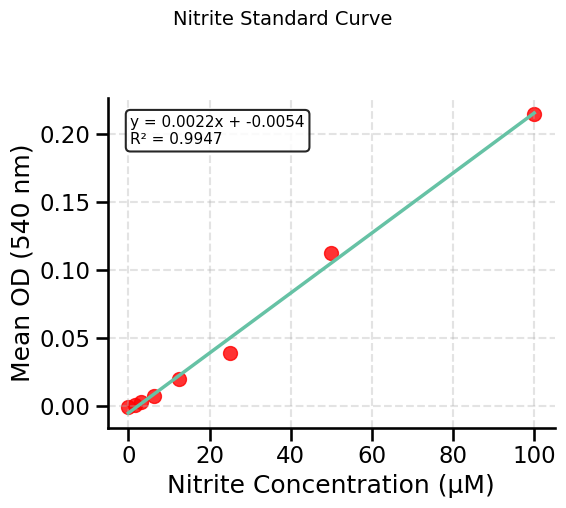

🌟 Does the plot look as you would expect? Where are the values you calculated above?
✅ Standard curve fitted!


In [ ]:
# ====================================================================
# Step 3.8 Plot the standard curve 🧱🧱🧱 Plotting the line from above
# ====================================================================

g = sns.lmplot(
    data=std_curve_summary,
    x="Nitrite_uM",
    y="Mean_OD",
    ci=None,
    height=5,
    aspect=1.2,
    scatter_kws={"s": 100, "alpha": 0.8, "color": "red"},
    line_kws={"linewidth": 2.5},
)
ax = g.axes[0, 0]
ax.text(
    0.05,
    0.95,
    f"y = {slope:.4f}x + {intercept:.4f}\nR² = {r_squared:.4f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
)
g.set_axis_labels("Nitrite Concentration (µM)", "Mean OD (540 nm)")
g.figure.suptitle("Nitrite Standard Curve", fontsize=14, y=1.03)
ax.grid(True, linestyle="--", alpha=0.35)

# Save as PNG (overwrites safely if re-run)
nitrate_curve_plot = "Assay3_nitrate_standard_curve.png"
plt.tight_layout()
plt.savefig(nitrate_curve_plot, dpi=300, bbox_inches="tight")
print(f"Saved: {nitrate_curve_plot}")

plt.show()

print(
    "🌟 Does the plot look as you would expect? Where are the values you calculated above?"
)
ok("Standard curve fitted!")

## Step 3.9 - Use the standard curve to estimate the nitrate concentration of the samples

**What this code cell does (Step 3.9 — Convert OD to nitrite concentrations)**

- Uses the fitted line to convert each sample OD value into a nitrite concentration:  
  **concentration = (OD − intercept) / slope**
- Clips concentrations to 0 (because negative concentration is not physically meaningful).
- Averages replicate rows, then groups wells into conditions (Control, LPS, Unknown, UNK+LPS) based on the column names.
- Validates that each condition has the expected number of replicates and prints mean ± SD for a quick summary.

In [ ]:
# ============================================================
# Step 3.9: Convert sample OD values to nitrite concentrations
# ============================================================
# Just find and answer the question!

# Using the standard curve equation: concentration = (OD - intercept) / slope

# --- Validation ---
assert slope != 0, "Cannot divide by zero slope ❌"

# --- Convert OD to concentration ---
# 🌟 Why do we need the standard curve?
# 🌟 Why do we do this calculation?
# 🌟 Can you tell this is important?
# 🌟 What if we repeated the experiment some other day?
sample_conc = (samples_final - intercept) / slope
sample_conc = sample_conc.clip(lower=0)  # Concentration cannot be negative


# ========================
# 🧱🧱🧱 We calculate the means of all the replicates for the plotting below
# ========================

# --- Calculate mean across replicate rows ---
sample_means = sample_conc.mean(axis=0)

# --- Group by condition (using string matching on index) ---
control = sample_means[sample_means.index.str.startswith("Control")].to_numpy()
lps = sample_means[sample_means.index.str.match(r"^LPS \d+$")].to_numpy()
unknown = sample_means[sample_means.index.str.match(r"^Unknown \d+$")].to_numpy()
unknown_lps = sample_means[sample_means.index.str.startswith("UNK+LPS")].to_numpy()

# --- Validation ---
assert len(control) == 3, f"Expected 3 Control values, got {len(control)} ❌"
assert len(lps) == 3, f"Expected 3 LPS values, got {len(lps)} ❌"
assert len(unknown) == 3, f"Expected 3 Unknown values, got {len(unknown)} ❌"
assert len(unknown_lps) == 3, f"Expected 3 UNK+LPS values, got {len(unknown_lps)} ❌"

# --- Print summary ---
print("Nitrite concentrations by condition (mean ± SD):")
print(f"  Control:  {control.mean():6.2f} ± {control.std():.2f} µM")
print(f"  LPS:      {lps.mean():6.2f} ± {lps.std():.2f} µM")
print(f"  Unknown:  {unknown.mean():6.2f} ± {unknown.std():.2f} µM")
print(f"  UNK+LPS:  {unknown_lps.mean():6.2f} ± {unknown_lps.std():.2f} µM\n")

ok("Concentrations calculated!")

print("🌟 Why do you think we calculated the means of the replicates?")
print("🌟 What makes replicates so essential in almost all experiments?")
print(
    "🌟 If you compare the mean and the standard deviation (SD), what does it tell you?"
)

Nitrite concentrations by condition (mean ± SD):
  Control:   39.26 ± 40.08 µM
  LPS:      218.34 ± 9.32 µM
  Unknown:  139.64 ± 185.95 µM
  UNK+LPS:  170.16 ± 202.44 µM

✅ Concentrations calculated!
🌟 Why do you think we calculated the means of the replicates?
🌟 What makes replicates so essential in almost all experiments?
🌟 If you compare the mean and the standard deviation (SD), what does it tell you?


## Step 3.10 - Create a bar plot comparing conditions

**What this code cell does (Step 3.10 — Bar plot by condition + export)**

- Builds a “tidy” table (`plot_data`) with one row per measurement and a `Condition` label.
- Computes summary statistics per condition and exports them to an Excel file.
- Creates a comparison plot:
  - individual replicate points (strip plot),
  - error bars, and
  - a highlighted mean marker for each condition.
- Saves the figure as a PNG so you can include it in your report.


Saved: Assay3_nitrate_concentration_plot.png


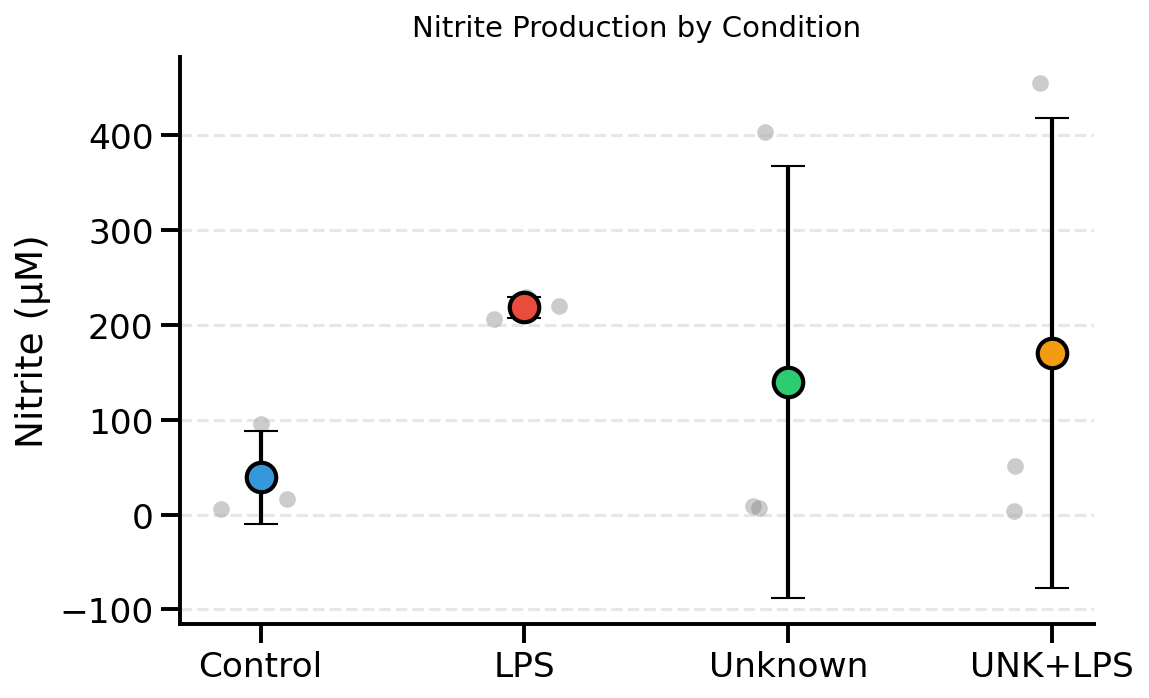

✅ The important plot created!


In [ ]:
# ==================================================
# Step 3.10: Create a bar plot comparing conditions
# ==================================================
# Shows mean ± SEM for each condition with individual data points

# 🌟 EDIT THESE: Customize your plot labels
PLOT_TITLE = "Nitrite Production by Condition"
Y_AXIS_LABEL = "Nitrite (µM)"

# --- Build tidy DataFrame for plotting ---
CONDITIONS = ["Control", "LPS", "Unknown", "UNK+LPS"]
COLORS = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12"]  # Blue, Red, Green, Orange


# ========================
# 🧱🧱🧱 Below is just some boilerplate code for plotting your results. You can skip it.
# ========================

all_values = list(control) + list(lps) + list(unknown) + list(unknown_lps)
all_conditions = ["Control"] * 3 + ["LPS"] * 3 + ["Unknown"] * 3 + ["UNK+LPS"] * 3

plot_data = pd.DataFrame({"Condition": all_conditions, "Nitrite": all_values})
plot_data["Condition"] = pd.Categorical(
    plot_data["Condition"], categories=CONDITIONS, ordered=True
)

# --- Calculate summary statistics ---
summary_stats = (
    plot_data.groupby("Condition", observed=True)["Nitrite"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# Export summary stats to Excel
summary_stats.to_excel("Assay3_nitrate_results.xlsx", index=False)


# --- Create plot ---
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

# Plot individual points (behind)
sns.stripplot(
    data=plot_data,
    x="Condition",
    y="Nitrite",
    order=CONDITIONS,
    color="gray",
    alpha=0.4,
    jitter=0.15,
    size=8,
    ax=ax,
    zorder=1,
)

# Plot error bars
ax.errorbar(
    x=range(len(CONDITIONS)),
    y=summary_stats["mean"],
    yerr=summary_stats["std"],
    fmt="none",
    ecolor="black",
    elinewidth=2,
    capsize=8,
    zorder=2,
)

# Plot mean dots (on top)
for i, cond in enumerate(CONDITIONS):
    mean_val = summary_stats.loc[summary_stats["Condition"] == cond, "mean"].iloc[0]
    ax.scatter(
        i, mean_val, s=200, color=COLORS[i], edgecolor="black", linewidth=2, zorder=3
    )

# --- Styling ---
ax.set_title(PLOT_TITLE, fontsize=14, pad=10)
ax.set_ylabel(Y_AXIS_LABEL)
ax.set_xlabel("")
ax.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()

# Save as PNG (overwrites safely if re-run)

plt.tight_layout()
plt.savefig("Assay3_nitrate_concentration_plot.png", dpi=300, bbox_inches="tight")
print(f"Saved: Assay3_nitrate_concentration_plot.png")

plt.show()

ok("The important plot created!")


## Step 3.11 - Interaction testing

The statistics get a little hairy here but stay with me. Sometimes, we want to do an interactions test to see if something has a different effect in different conditions. For example, we can test how nice ice cream is in itself. We can also test how nice ice cream is in summer or winter. Similarly, we can test how inflammatory LPS is in Controls or our Compound. Last edition of this notebook had you perform something like

>🧱
>an ANOVA model with an interaction term and used Post-Hoc analysis to do a multiple comparison of means using Tukey's Honestly Significant Difference (HSD)  while controlling the Family-wise Error Rate (FWER) at alpha = 0.05 and they find a p-value of 0.13 thereby they fail to reject the null hypothesis (H0) that the conditional effect of LPS is 0
>🧱

We are not doing that this year. Below, I have created an interaction plot. If you promise to look carefully at it, you don't have to know what FWER means in this semester.

**What this code cell does (Step 3.11 — Interaction plot)**

- Re-structures the data into a two-factor design:
  - **Treatment:** Control vs Unknown  
  - **LPS:** No LPS vs +LPS
- Calculates mean and SEM for each combination, then plots:
  - two lines (Control and Unknown),
  - mean points with SEM error bars.
- Computes a simple “interaction estimate” (difference-of-differences) to quantify whether the Unknown changes the LPS response.


Saved: Assay3_nitrate_interaction_plot.png


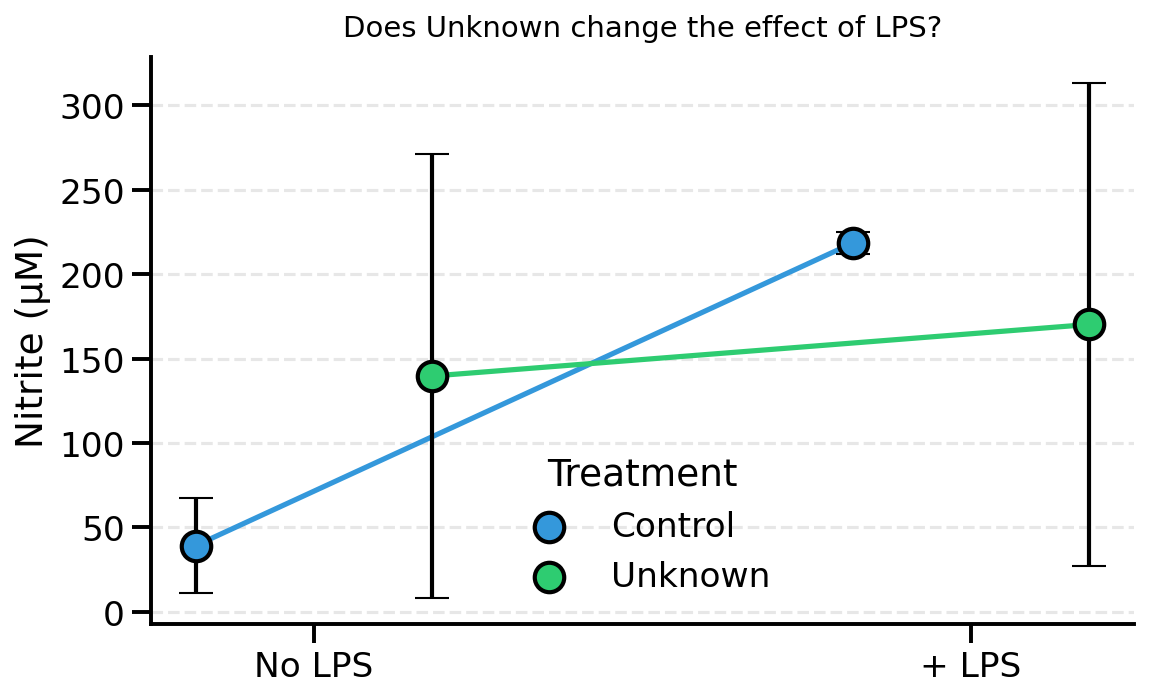

LPS effect in Control:  +179.07 µM
LPS effect in Unknown:  +30.52 µM
Interaction estimate:   -148.55 µM
✅ Interaction plot created!


In [ ]:
# ===========================
# Step 3.11: Interaction plot
# ===========================

PLOT_TITLE = "Does Unknown change the effect of LPS?"
Y_AXIS_LABEL = "Nitrite (µM)"

# Two lines: Control vs Unknown
TREATMENTS = ["Control", "Unknown"]
LPS_LEVELS = ["No LPS", "+ LPS"]

# Match your Step 9 style: blue + green
TREATMENT_COLORS = {"Control": "#3498db", "Unknown": "#2ecc71"}

# ========================
# 🧱🧱🧱 Plotting code below. Just look at the figure
# ========================

# --- Build tidy DataFrame (derive lengths instead of hard-coding 3) ---
interaction_data = pd.DataFrame(
    {
        "Nitrite": np.concatenate([control, lps, unknown, unknown_lps]),
        "Treatment": (
            ["Control"] * len(control)
            + ["Control"] * len(lps)
            + ["Unknown"] * len(unknown)
            + ["Unknown"] * len(unknown_lps)
        ),
        "LPS": (
            ["No LPS"] * len(control)
            + ["+ LPS"] * len(lps)
            + ["No LPS"] * len(unknown)
            + ["+ LPS"] * len(unknown_lps)
        ),
    }
)

interaction_data["Treatment"] = pd.Categorical(
    interaction_data["Treatment"], categories=TREATMENTS, ordered=True
)
interaction_data["LPS"] = pd.Categorical(
    interaction_data["LPS"], categories=LPS_LEVELS, ordered=True
)

# --- Summary stats (mean ± SEM) ---
summary = (
    interaction_data.groupby(["Treatment", "LPS"], observed=True)["Nitrite"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
summary["sem"] = summary["std"] / np.sqrt(summary["count"])

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

# 2) Lines + mean dots + whiskers per treatment
x_pos = {lvl: i for i, lvl in enumerate(LPS_LEVELS)}
dodge = 0.18  # horizontal separation between Control and Unknown at each LPS level
offset = {"Control": -dodge, "Unknown": +dodge}

for tr in TREATMENTS:
    tr_color = TREATMENT_COLORS[tr]

    # Pull means/SEMs in the correct order
    means = []
    sems = []
    xs = []
    for lvl in LPS_LEVELS:
        row = summary[(summary["Treatment"] == tr) & (summary["LPS"] == lvl)].iloc[0]
        means.append(row["mean"])
        sems.append(row["sem"])
        xs.append(x_pos[lvl] + offset[tr])

    # Connect means with a line
    ax.plot(xs, means, linewidth=2.5, color=tr_color, zorder=2)

    # Whiskers (mean ± SEM)
    ax.errorbar(
        xs,
        means,
        yerr=sems,
        fmt="none",
        ecolor="black",
        elinewidth=2,
        capsize=8,
        zorder=3,
    )

    # Mean dots (big, colored, black edge)
    ax.scatter(
        xs,
        means,
        s=200,
        color=tr_color,
        edgecolor="black",
        linewidth=2,
        zorder=4,
        label=tr,
    )

# --- Styling (match Step 9) ---
ax.set_title(PLOT_TITLE, fontsize=14, pad=10)
ax.set_ylabel(Y_AXIS_LABEL)
ax.set_xlabel("")
ax.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()
ax.set_xticks(range(len(LPS_LEVELS)))
ax.set_xticklabels(LPS_LEVELS)

ax.legend(title="Treatment", frameon=False)
plt.tight_layout()

plt.savefig("Assay3_nitrate_interaction_plot.png", dpi=300, bbox_inches="tight")
print(f"Saved: Assay3_nitrate_interaction_plot.png")

plt.show()

# --- Print the interaction estimate (difference-of-differences) ---
lps_effect_control = float(np.mean(lps) - np.mean(control))
lps_effect_unknown = float(np.mean(unknown_lps) - np.mean(unknown))
interaction = lps_effect_unknown - lps_effect_control

print(f"LPS effect in Control:  {lps_effect_control:+.2f} µM")
print(f"LPS effect in Unknown:  {lps_effect_unknown:+.2f} µM")
print(f"Interaction estimate:   {interaction:+.2f} µM")
ok("Interaction plot created!")


## Assay 3 - Interpretation

Look at the "Nitrate Concentration by Condition" and the "Interaction" plots. Also, look at the summary data frame:

1) Which is highest, Control or LPS? Does that make sense given what you know about the experiment?
2) We are looking for differences in slope between the two lines. Is there one?
3) If you look at the error bars, do you think the difference in slopes is actually real and meaningful? Could it be just random?
4) Think carefully what this means for your compound. Does the line slope up? Down? Flat?
5) What can you conclude about your compound from looking at this plot? 🌟🌟🌟

### Write down your conclusions ✍️🧑‍💻

# Final Summary



### Evaluating the response of each unknown  compound across all three assays

In the first part of this notebook (see the opening *goal* and the assay sections that follow), you transformed raw plate readouts into **interpretable results**: plots, summary statistics, and comparisons to the relevant controls (e.g., untreated control, LPS, etc.).  

Now we do the *most important step of the exercise*: **turning data into a defensible interpretation**.

### What you will do
For each compound (Unknown A–D) and for each assay (Assay 1–3), you will assign **one** of these outcomes:

- **Affected** — the unknown produces a clear and reproducible change relative to the controls in this assay.
- **Not affected** — the unknown looks similar to the negative control (no consistent change beyond normal variability).
- **Inconclusive** — the data are too noisy, contradictory, or borderline to confidently decide.

>🚨🚨🚨 **Note**: For the Assay 3, combine the results with your colleagues to fill the table below for the **4 unknown compounds.**

You will record your decisions in the interactive table below.

### How to decide (use the same logic for every assay)
1. **Check the controls first**
   - Do the control and positive control behave as expected?
   - If controls look wrong, results may be unreliable → lean toward **Inconclusive**.

2. **Compare the unknown to the relevant baseline**
   - Use the plots and summary values you already computed.
   - Ask: is the unknown separated from the control by more than typical scatter/SD?

3. **Look for consistency**
   - Are replicates similar?
   - Do repeated patterns appear across concentrations/conditions (if applicable)?
   - A one-off outlier is not enough to call **Affected**.

4. **Make the call using this rubric**
   - **Affected**: consistent difference vs control (direction + magnitude), not driven by a single point, and fits the assay’s biology.
   - **Not affected**: values overlap with control, no consistent shift or trend.
   - **Inconclusive**: high variability, conflicting replicates, ambiguous direction, or questionable control performance.


---
### Group discussion

Once everyone has filled in the matrix, we will compare patterns across assays:
- Do any unknowns look **toxic** (e.g., membrane damage) vs **metabolically disruptive** vs **inflammatory-modulating**?
- Do the assays agree or disagree—and what biological explanations could account for that?
- Where are our strongest conclusions, and where do we need better data?

*Tip:* If you mark something **Affected** or **Inconclusive**, be ready to explain *what in the data* led you there.




In [ ]:
# ======================================================
# Interactive IPython widget to collect analysis results
# =======================================================

import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Configure ---
unknowns = ["Unknown A", "Unknown B", "Unknown C", "Unknown D"]
assays = ["Assay 1 (MMC/JC1)", "Assay 2 (LDH)", "Assay 3 (Griess)"]
choices = ["Affected", "Not affected", "Inconclusive"]

# This DataFrame will hold the students' final calls (available after running this cell)
assay_calls = pd.DataFrame(index=unknowns, columns=assays, dtype="object")

# --- Build widget grid ---
dropdowns = {}  # (unknown, assay) -> Dropdown

grid = widgets.GridspecLayout(len(unknowns) + 1, len(assays) + 1, grid_gap="8px")

grid[0, 0] = widgets.HTML("<b>Compound</b>")
for j, assay in enumerate(assays):
    grid[0, j + 1] = widgets.HTML(f"<b>{assay}</b>")

for i, unk in enumerate(unknowns):
    grid[i + 1, 0] = widgets.HTML(unk)
    for j, assay in enumerate(assays):
        dd = widgets.Dropdown(
            options=[""] + choices,
            value="",
            layout=widgets.Layout(width="170px")
        )
        dropdowns[(unk, assay)] = dd
        grid[i + 1, j + 1] = dd

out = widgets.Output()

def sync_to_dataframe(*_):
    """Copy widget selections -> assay_calls DataFrame and display it."""
    for unk in unknowns:
        for assay in assays:
            val = dropdowns[(unk, assay)].value
            assay_calls.loc[unk, assay] = val if val != "" else pd.NA

    with out:
        clear_output()
        display(assay_calls)

# Auto-update whenever a dropdown changes
for dd in dropdowns.values():
    dd.observe(sync_to_dataframe, names="value")

# Buttons: (optional) manual refresh + export
btn_refresh = widgets.Button(description="Refresh table", icon="refresh")
btn_refresh.on_click(sync_to_dataframe)

file_name = widgets.Text(value="K1_full_summary_all_assays.xlsx", description="Excel file:", layout=widgets.Layout(width="350px"))
btn_export = widgets.Button(description="Export to Excel", icon="download")

def export_to_excel(_):
    sync_to_dataframe()
    assay_calls.to_excel(file_name.value, sheet_name="Assay calls")
    with out:
        print(f"\nSaved: {file_name.value}")

btn_export.on_click(export_to_excel)

display(grid, widgets.HBox([btn_refresh, file_name, btn_export]), out)

# Initialize display once
sync_to_dataframe()


GridspecLayout(children=(HTML(value='<b>Compound</b>', layout=Layout(grid_area='widget001')), HTML(value='<b>A…

Output()

### Visual summary (heatmap)

The plot below is a compact way to view your final interpretation table (`assay_summary`).  
- **Rows** are the unknown compounds (A–D).  
- **Columns** are the three assays.  
- Each **cell** is your assigned outcome (**Affected**, **Not affected**, or **Inconclusive**).

The heatmap makes it easy to spot patterns across assays (e.g., an unknown that is consistently *Affected* in multiple assays, or one that only changes in a single assay). The text labels are written directly in each cell, so you can read the exact call even if the colors look similar.


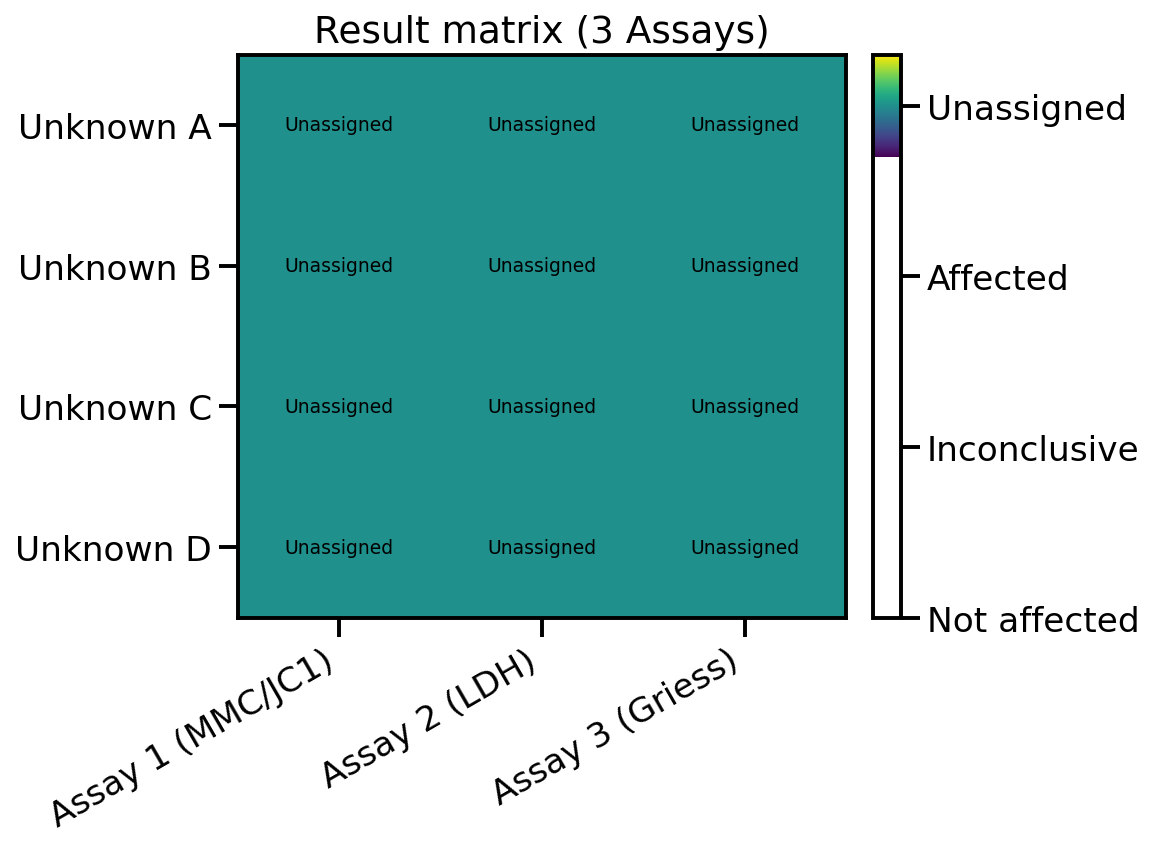

In [ ]:
# ====================================
# Plotting a visual summary (heatmap)
# ====================================

# Basic safety checks
assert isinstance(assay_calls, pd.DataFrame), "assay_calls must be a pandas DataFrame."
assert assay_calls.shape[0] > 0 and assay_calls.shape[1] > 0, "assay_calls looks empty."

# Convert categories -> numeric codes for heatmap
calls_text = assay_calls.copy()
calls_text = calls_text.fillna("Unassigned")

code_map = {
    "Not affected": 0,
    "Inconclusive": 1,
    "Affected": 2,
    "Unassigned": 3,
}

codes = calls_text.replace(code_map).to_numpy()

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
im = ax.imshow(codes, aspect="auto")

# Axis labels
ax.set_xticks(np.arange(calls_text.shape[1]))
ax.set_xticklabels(calls_text.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(calls_text.shape[0]))
ax.set_yticklabels(calls_text.index)

ax.set_title("Result matrix (3 Assays)")

# Annotate each cell with the text label (so it’s readable even without the colorbar)
for i in range(calls_text.shape[0]):
    for j in range(calls_text.shape[1]):
        ax.text(j, i, calls_text.iat[i, j], ha="center", va="center", fontsize=9)

# Colorbar with categorical tick labels
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_ticks([0, 1, 2, 3])
cbar.set_ticklabels(["Not affected", "Inconclusive", "Affected", "Unassigned"])

plt.tight_layout()
plt.savefig("Summary_K1_assays_interpretation_matrix.png", dpi=300, bbox_inches="tight")

plt.show()



## Download your results

Downloading your outputs from Colab (as a ZIP)

Colab runs in a temporary “runtime” environment. Any files you create (Excel exports, CSV summaries, figures, etc.) are saved inside the runtime filesystem (usually in /content). To make it easy to take everything with you at the end of the analysis, the next code cell:

* Collects all files in the current working directory (and subfolders)

* Creates one ZIP archive called colab_runtime_files.zip

D* ownloads the ZIP to your computer using Colab’s built-in download helper

> **Important Note:** the ZIP is recreated each time you run the cell (the previous ZIP is overwritten).


Since the runtime is temporary, download your files before you disconnect/reset the runtime or leave Google Colabr.

In [ ]:
# ================================
# Zip and Download all results
# ================================

# Colab convenience: zip & download all files from the runtime working directory
try:
    import os, zipfile
    from pathlib import Path

    from google.colab import files  # type: ignore

    base_dir = Path.cwd()              # usually /content
    zip_path = base_dir / "K1_data_analysis.zip"

    # Create zip (overwrite if exists)
    if zip_path.exists():
        zip_path.unlink()

    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for p in base_dir.rglob("*"):
            # skip directories, the zip itself, and hidden runtime folders
            if p.is_dir():
                continue
            if p == zip_path:
                continue
            if any(part.startswith(".") for part in p.relative_to(base_dir).parts):
                continue

            zf.write(p, arcname=p.relative_to(base_dir))

    files.download(str(zip_path))
except Exception:
    pass

ok("Summary tables saved (CSV + Excel).")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Summary tables saved (CSV + Excel).
